In [1]:
# Persistent imports and silent installer
import importlib, subprocess, sys, os
venv_site_packages = os.path.abspath('.venv/Lib/site-packages')
if os.path.isdir(venv_site_packages) and venv_site_packages not in sys.path:
    sys.path.insert(0, venv_site_packages)
def _silent_install(packages):
    import importlib, subprocess, sys, os
    for pkg in packages:
        try:
            importlib.import_module(pkg)
        except Exception:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Module names (importable names) to ensure available. Update as needed.
required = ['numpy','scipy','matplotlib','scikit-learn','pandas','tqdm']
_silent_install(required)
# Standard imports used across the notebook
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import model_selection, metrics
plt.rcParams['figure.dpi'] = 120
# Reduce noisy outputs (warnings)
import warnings
warnings.filterwarnings('ignore')
print('Using extra site-packages from:', venv_site_packages)

Using extra site-packages from: c:\Users\Uni\Desktop\ML Lab\Ex3\.venv\Lib\site-packages


In [2]:
import sys
import flax
print('sys.executable:', sys.executable)
print('flax version:', flax.__version__)

sys.executable: c:\Users\Uni\Desktop\ML Lab\Ex3\.venv\Scripts\python.exe
flax version: 0.12.7


In [3]:
print('No extra install needed here.')
print('Run Cell 1 first to expose packages from .venv to this notebook kernel.')

No extra install needed here.
Run Cell 1 first to expose packages from .venv to this notebook kernel.


# 389.204 MLA - Exercise 3 - Neural Networks, Backprop (Skeleton)

**Date:** 15. May 2026

---

# Problem 3.1 (25%)

Consider the simple two layer neural network with three neurons in total depicted in Figure 3.1.1. Here, the input consists of the vector:

$$x = [x_0, x_1]^T$$

while the output is given by the scalar:

$$\hat{y}$$

For each neuron (j) in layer (i), the activation is computed according to the following affine transformation:

$$a_j^{(i)} = w_j^{(i)} z^{(i-1)} + b_j^{(i)} \tag{3.1.1}$$

before the activation function:

$$\sigma_j^{(i)}(\cdot)$$

is applied to form the final output:

$$z_j^{(i)} = \sigma_j^{(i)}(a_j^{(i)})$$

In the following, we will assume linear or relu activation functions.

---

## 3.1.1

Task: Find a configuration of the network that approximates XOR without error. (Do not write solutions here.)

Fill Table 3.1.1 below (leave blanks for your answers):

### Table 3.1.1: Network output and activations

| (x^\top) | (y) | (a_0^{(0)}) | (z_0^{(0)}) | (a_1^{(0)}) | (z_1^{(0)}) | (a_0^{(1)}) | (\hat{y} = z_0^{(1)}) |
| -------- | --- | ----------- | ----------- | ----------- | ----------- | ----------- | --------------------- |
| [0,0]    | 0   |             |             |             |             |             |                       |
| [0,1]    | 1   |             |             |             |             |             |                       |
| [1,0]    | 1   |             |             |             |             |             |                       |
| [1,1]    | 0   |             |             |             |             |             |                       |

---

## Results — 3.1.1

In the report

## 3.1.2

Task: Derive analytical expressions for gradients of L(w,b) = (y - \hat{y})^2 with respect to specified parameters. (Do not include solutions here.)

---

## Results — 3.1.2

In the report

## 3.1.3

Task: Implement the network from scratch using JAX and adapt `problem_skeleton_logical_and.py`. Train and report final weights/biases. 

---

In [4]:
!pip install --quiet --upgrade jax jaxlib
import jax
import jax.numpy as jnp

# =================================================
# Dataset: Logical AND
# =================================================

X = jnp.array([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = jnp.array([
    [0.],
    [0.],
    [0.],
    [1.]
])

# =================================================
# Parameter Initialization
# =================================================

key = jax.random.PRNGKey(0)

key1, key2 = jax.random.split(key)

params = {
    "W1": jax.random.normal(key1, (2, 2)) * 0.1,
    "b1": jnp.zeros((2,)),
    "W2": jax.random.normal(key2, (2, 1)) * 0.1,
    "b2": jnp.zeros((1,))
}

# =================================================
# Activation Functions
# =================================================

def relu(x):
    return jnp.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

# =================================================
# Forward Pass
# =================================================

def forward(params, X):

    # Hidden layer
    a1 = jnp.dot(X, params["W1"]) + params["b1"]
    z1 = relu(a1)

    # Output layer
    a2 = jnp.dot(z1, params["W2"]) + params["b2"]
    y_hat = sigmoid(a2)

    return y_hat

# =================================================
# Binary Cross Entropy Loss
# =================================================

def loss_fn(params, X, y):

    y_hat = forward(params, X)

    eps = 1e-7

    loss = -jnp.mean(
        y * jnp.log(y_hat + eps)
        + (1 - y) * jnp.log(1 - y_hat + eps)
    )

    return loss

# =================================================
# Training Step
# =================================================

learning_rate = 0.1

@jax.jit
def update(params, X, y):

    grads = jax.grad(loss_fn)(params, X, y)

    params = {
        "W1": params["W1"] - learning_rate * grads["W1"],
        "b1": params["b1"] - learning_rate * grads["b1"],
        "W2": params["W2"] - learning_rate * grads["W2"],
        "b2": params["b2"] - learning_rate * grads["b2"]
    }

    return params

# =================================================
# Training Loop
# =================================================

epochs = 5000

for epoch in range(epochs):

    params = update(params, X, y)

    if epoch % 500 == 0:

        loss = loss_fn(params, X, y)

        print(f"Epoch {epoch}: Loss = {loss:.6f}")

# =================================================
# Final Predictions
# =================================================

predictions = forward(params, X)

print("\nPredictions:")
print(predictions)

print("\nLearned Parameters:")
for key, value in params.items():
    print(f"\n{key}:")
    print(value)

Epoch 0: Loss = 0.684627
Epoch 500: Loss = 0.127267
Epoch 1000: Loss = 0.033435
Epoch 1500: Loss = 0.017311
Epoch 2000: Loss = 0.011350
Epoch 2500: Loss = 0.008354
Epoch 3000: Loss = 0.006590
Epoch 3500: Loss = 0.005414
Epoch 4000: Loss = 0.004577
Epoch 4500: Loss = 0.003966

Predictions:
[[1.5522137e-07]
 [1.2602997e-03]
 [9.8420109e-04]
 [9.8834562e-01]]

Learned Parameters:

W1:
[[ 0.7782524  -2.5447009 ]
 [-2.432975   -0.91024524]]

W2:
[[-3.0394044]
 [-4.370314 ]]

b1:
[1.653354  3.4536526]

b2:
[4.4403443]


## Results — 3.1.3

Results: 

# Problem 3.2 (25%)

Learning curves and Flax implementations. Implement the networks from Figures 3.2.1 and 3.2.2.

## Implementation guideline (mandatory)

Use `problem_skeleton_flax_keras_like.py` and structure using the listed components.

---

## 3.2.1

Task: Implement both models using Flax. (No solutions provided here.)

---

In [9]:
!pip install --quiet --upgrade optax flax orbax

from __future__ import annotations
import dataclasses
import os
from dataclasses import dataclass
from typing import Any, Callable, Dict, Iterator, Optional, Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import orbax.checkpoint as ocp
import pandas as pd
from flax import nnx
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

Array = jax.Array
Batch = Tuple[Array, Array, Array]
Metrics = Dict[str, Array]


@dataclass(frozen=True)
class DataConfig:
    seed: int = 0
    batch_size: int = 64
    test_batch_size: Optional[int] = None
    test_size: float = 0.3
    shuffle_train: bool = True
    drop_last: bool = False
    stratify: bool = False


@dataclass(frozen=True)
class Config:
    seed: int = 0
    epochs: int = 50
    steps_per_epoch: Optional[int] = None

    lr: float = 1e-3
    optim: str = "adam"
    momentum: float = 0.9
    weight_decay: float = 0.0
    clip_norm: Optional[float] = None

    in_dim: int = 10
    hidden_dims: Tuple[int, ...] = (128, 128, 128)
    out_dim: int = 3
    dropout: float = 0.0

    data: DataConfig = dataclasses.field(default_factory=DataConfig)


def _pad_batch(xb: np.ndarray, batch_size: int) -> np.ndarray:
    if xb.shape[0] == batch_size:
        return xb
    pad = batch_size - xb.shape[0]
    return np.pad(
        xb,
        pad_width=[(0, pad)] + [(0, 0)] * (xb.ndim - 1),
        mode="constant",
    )


def _make_batches_jax(
    X: np.ndarray,
    y: np.ndarray,
    *,
    batch_size: int,
    seed: int,
    shuffle: bool,
    repeat: bool,
    drop_last: bool,
) -> Iterator[Batch]:
    n = int(X.shape[0])
    key = jax.random.PRNGKey(seed)

    while True:
        if shuffle:
            key, sub = jax.random.split(key)
            idx = np.asarray(jax.random.permutation(sub, n))
        else:
            idx = np.arange(n)

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_idx = idx[start:end]
            actual = end - start

            if actual < batch_size and drop_last:
                continue

            xb = _pad_batch(np.asarray(X[batch_idx]), batch_size).astype(np.float32)
            yb = _pad_batch(np.asarray(y[batch_idx]), batch_size).astype(np.float32)

            mask = np.zeros((batch_size,), dtype=np.float32)
            mask[:actual] = 1.0

            yield jnp.asarray(xb), jnp.asarray(yb), jnp.asarray(mask)

        if not repeat:
            break


class DataModule:
    def __init__(self, cfg: Config, X_train: Any, y_train: Any, X_test: Any, y_test: Any):
        self.cfg = cfg
        self.X_train = np.asarray(X_train, dtype=np.float32)
        self.y_train = np.asarray(y_train, dtype=np.float32)
        self.X_test = np.asarray(X_test, dtype=np.float32)
        self.y_test = np.asarray(y_test, dtype=np.float32)

    @classmethod
    def from_arrays(cls, cfg: Config, *, X: Any, y: Any, stratify_labels: Any = None) -> "DataModule":
        X_np = np.asarray(X, dtype=np.float32)
        y_np = np.asarray(y, dtype=np.float32)
        stratify = stratify_labels if cfg.data.stratify else None
        Xtr, Xte, ytr, yte = train_test_split(
            X_np,
            y_np,
            test_size=cfg.data.test_size,
            random_state=cfg.data.seed,
            shuffle=True,
            stratify=stratify,
        )
        return cls(cfg, Xtr, ytr, Xte, yte)

    @classmethod
    def from_splits(
        cls,
        cfg: Config,
        *,
        Xtr: Any,
        Xte: Any,
        ytr: Any,
        yte: Any,
    ) -> "DataModule":
        return cls(cfg, Xtr, ytr, Xte, yte)

    @classmethod
    def from_csv(
        cls,
        cfg: Config,
        *,
        csv_path: str,
        label_col: str,
        stratify_labels: Any = None,
    ) -> "DataModule":
        df = pd.read_csv(csv_path)
        X_np = df.drop(columns=[label_col]).to_numpy(dtype=np.float32)
        y_np = df[label_col].to_numpy()
        return cls.from_arrays(cfg, X=X_np, y=y_np, stratify_labels=stratify_labels)

    def train_iter(self) -> Iterator[Batch]:
        return _make_batches_jax(
            self.X_train,
            self.y_train,
            batch_size=self.cfg.data.batch_size,
            seed=self.cfg.data.seed + 1,
            shuffle=self.cfg.data.shuffle_train,
            repeat=True,
            drop_last=self.cfg.data.drop_last,
        )

    def test_iter(self) -> Iterator[Batch]:
        return _make_batches_jax(
            self.X_test,
            self.y_test,
            batch_size=self.cfg.data.test_batch_size or self.cfg.data.batch_size,
            seed=self.cfg.data.seed + 2,
            shuffle=False,
            repeat=False,
            drop_last=False,
        )


class MLPNetwork(nnx.Module):
    def __init__(self, cfg: Config, *, rngs: nnx.Rngs):
        self.cfg = cfg
        dims = (cfg.in_dim,) + tuple(cfg.hidden_dims)
        self.hidden_layers = nnx.List(
            [nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)]
        )
        self.output_layer = nnx.Linear(dims[-1], cfg.out_dim, rngs=rngs)
        self.dropout = nnx.Dropout(rate=cfg.dropout, rngs=rngs) if cfg.dropout > 0.0 else None

    def __call__(self, x: Array) -> Array:
        for layer in self.hidden_layers:
            x = nnx.relu(layer(x))
            if self.dropout is not None:
                x = self.dropout(x)
        return self.output_layer(x)


class ProbabilisticMLP(nnx.Module):
    def __init__(self, cfg: Config, *, rngs: nnx.Rngs):
        self.cfg = cfg
        dims = (cfg.in_dim,) + tuple(cfg.hidden_dims)
        self.hidden_layers = nnx.List(
            [nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)]
        )
        self.mu_head = nnx.Linear(dims[-1], 1, rngs=rngs)
        self.log_var_head = nnx.Linear(dims[-1], 1, rngs=rngs)
        self.dropout = nnx.Dropout(rate=cfg.dropout, rngs=rngs) if cfg.dropout > 0.0 else None

    def __call__(self, x: Array) -> Array:
        for layer in self.hidden_layers:
            x = nnx.relu(layer(x))
            if self.dropout is not None:
                x = self.dropout(x)
        mu = self.mu_head(x)
        log_var = self.log_var_head(x)
        return jnp.concatenate([mu, log_var], axis=-1)


NetworkFactory = Callable[[Config, nnx.Rngs], nnx.Module]
LossFn = Callable[[Array, Array, Array], Tuple[Array, Metrics]]


def make_mlp_network(cfg: Config, rngs: nnx.Rngs) -> nnx.Module:
    return MLPNetwork(cfg, rngs=rngs)


def make_probabilistic_network(cfg: Config, rngs: nnx.Rngs) -> nnx.Module:
    return ProbabilisticMLP(cfg, rngs=rngs)


def make_optax_tx(cfg: Config):
    name = cfg.optim.lower()
    if name == "adam":
        tx = optax.adam(cfg.lr)
    elif name == "adamw":
        tx = optax.adamw(cfg.lr, weight_decay=cfg.weight_decay)
    elif name == "sgd":
        tx = optax.sgd(cfg.lr, momentum=cfg.momentum)
    else:
        raise ValueError(f"Unknown optimizer: {cfg.optim}")

    if cfg.clip_norm is not None:
        tx = optax.chain(optax.clip_by_global_norm(cfg.clip_norm), tx)
    return tx


def copy_state(state):
    return jax.tree_util.tree_map(
        lambda x: x.copy() if hasattr(x, "copy") else x,
        state,
    )


class Model:
    def __init__(self, cfg: Config, dm: DataModule, network_fn: NetworkFactory, loss_fn: LossFn):
        self.cfg = cfg
        self.dm = dm
        self.network_fn = network_fn
        self.loss_fn = loss_fn

        self.network: Optional[nnx.Module] = None
        self.optimizer: Optional[nnx.Optimizer] = None

        self._train_step = self.make_train_step()
        self._eval_step = self.make_eval_step()
        self._predict_step = self.make_predict_step()

    def init(self) -> None:
        x0, _, _ = next(self.dm.train_iter())
        if x0.shape[-1] != self.cfg.in_dim:
            raise ValueError(
                f"Config.in_dim={self.cfg.in_dim} but batch has last dim {x0.shape[-1]}"
            )

        rngs = nnx.Rngs(self.cfg.seed)
        self.network = self.network_fn(self.cfg, rngs)
        self.optimizer = nnx.Optimizer(self.network, make_optax_tx(self.cfg), wrt=nnx.Param)

        if self.cfg.steps_per_epoch is None:
            n_train = int(self.dm.X_train.shape[0])
            bsz = int(self.cfg.data.batch_size)
            steps = n_train // bsz if self.cfg.data.drop_last else (n_train + bsz - 1) // bsz
            self.cfg = dataclasses.replace(self.cfg, steps_per_epoch=max(steps, 1))

    def make_train_step(self):
        @nnx.jit
        def train_step(network: nnx.Module, optimizer: nnx.Optimizer, batch: Batch) -> Metrics:
            x, y, mask = batch

            def _loss(current_network: nnx.Module):
                outputs = current_network(x)
                return self.loss_fn(outputs, y, mask)

            (_, metrics), grads = nnx.value_and_grad(_loss, has_aux=True)(network)
            optimizer.update(network, grads)
            return metrics

        return train_step

    def make_eval_step(self):
        @nnx.jit
        def eval_step(network: nnx.Module, batch: Batch) -> Metrics:
            x, y, mask = batch
            outputs = network(x)
            _, metrics = self.loss_fn(outputs, y, mask)
            return metrics

        return eval_step

    def make_predict_step(self):
        @nnx.jit
        def predict_step(network: nnx.Module, xb: Array):
            return network(xb)

        return predict_step

    def _merge_epoch_metrics(self, metric_sums: Dict[str, float], count_sum: float) -> Dict[str, float]:
        return {k: v / max(count_sum, 1.0) for k, v in metric_sums.items()}

    def evaluate(self) -> Dict[str, float]:
        assert self.network is not None
        self.network.eval()

        metric_sums: Dict[str, float] = {}
        count_sum = 0.0

        for batch in self.dm.test_iter():
            _, _, mask = batch
            valid_batch = float(jnp.sum(mask))
            count_sum += valid_batch

            metrics = jax.device_get(self._eval_step(self.network, batch))
            for key, value in metrics.items():
                metric_sums[key] = metric_sums.get(key, 0.0) + float(value) * valid_batch

        return self._merge_epoch_metrics(metric_sums, count_sum)

    def fit(
        self,
        *,
        min_delta: float = 0.0,
        patience: Optional[int] = None,
        monitor: str = "val_loss",
        mode: str = "min",
        restore_best: bool = False,
        verbose: bool = True,
    ) -> Dict[str, list]:
        if self.network is None or self.optimizer is None:
            self.init()

        assert self.network is not None
        assert self.optimizer is not None
        assert self.cfg.steps_per_epoch is not None

        history: Dict[str, list] = {}
        best_score = np.inf if mode == "min" else -np.inf
        best_state = None
        epochs_without_improvement = 0
        steps = int(self.cfg.steps_per_epoch)

        for epoch in range(1, self.cfg.epochs + 1):
            self.network.train()
            train_it = self.dm.train_iter()

            metric_sums: Dict[str, float] = {}
            count_sum = 0.0

            for _ in tqdm(range(steps), desc=f"Epoch {epoch}/{self.cfg.epochs}", leave=False):
                batch = next(train_it)
                _, _, mask = batch
                valid_batch = float(jnp.sum(mask))
                count_sum += valid_batch

                metrics = jax.device_get(self._train_step(self.network, self.optimizer, batch))
                for key, value in metrics.items():
                    metric_sums[key] = metric_sums.get(key, 0.0) + float(value) * valid_batch

            train_metrics = self._merge_epoch_metrics(metric_sums, count_sum)
            val_metrics = self.evaluate()

            epoch_metrics = dict(train_metrics)
            epoch_metrics.update({f"val_{key}": value for key, value in val_metrics.items()})

            for key, value in epoch_metrics.items():
                history.setdefault(key, []).append(float(value))

            if verbose:
                parts = [f"Epoch {epoch}/{self.cfg.epochs}"]
                for key, value in epoch_metrics.items():
                    parts.append(f"{key}={value:.4f}")
                tqdm.write(" | ".join(parts))

            if patience is not None:
                score = epoch_metrics[monitor]
                improved = (score < best_score - min_delta) if mode == "min" else (score > best_score + min_delta)
                if improved:
                    best_score = score
                    epochs_without_improvement = 0
                    if restore_best:
                        best_state = copy_state(nnx.state(self.network))
                else:
                    epochs_without_improvement += 1
                    if epochs_without_improvement >= patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch}")
                        break

        if restore_best and best_state is not None:
            nnx.update(self.network, best_state)

        return history

    def predict(self, X: Array, *, batch_size: Optional[int] = None):
        assert self.network is not None
        self.network.eval()

        X_np = np.asarray(X, dtype=np.float32)
        bs = batch_size or self.cfg.data.test_batch_size or self.cfg.data.batch_size
        outputs = []

        if len(X_np) == 0:
            return np.empty((0, self.cfg.out_dim), dtype=np.float32)

        for start in range(0, len(X_np), bs):
            end = min(start + bs, len(X_np))
            xb = _pad_batch(X_np[start:end], bs).astype(np.float32)
            actual = end - start
            batch_out = jax.device_get(self._predict_step(self.network, jnp.asarray(xb)))
            sliced = jax.tree_util.tree_map(lambda z: np.asarray(z[:actual]), batch_out)
            outputs.append(sliced)

        return jax.tree_util.tree_map(
            lambda *parts: np.concatenate(parts, axis=0),
            *outputs,
        )

    def predict_proba(self, X: Array, *, batch_size: Optional[int] = None) -> np.ndarray:
        logits = np.asarray(self.predict(X, batch_size=batch_size))
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)

    def save(self, path: str) -> None:
        assert self.network is not None
        ocp.PyTreeCheckpointer().save(os.path.abspath(path), {"network": nnx.state(self.network)}, force=True)

    def load(self, path: str) -> None:
        if self.network is None or self.optimizer is None:
            self.init()
        payload = ocp.PyTreeCheckpointer().restore(os.path.abspath(path))
        nnx.update(self.network, payload["network"])


dummy_x = jnp.ones((1, 10), dtype=jnp.float32)

print("\n================ BASELINE MODEL ================\n")
baseline_cfg = Config(in_dim=10, hidden_dims=(128, 128, 128), out_dim=3, dropout=0.0)
baseline_model = make_mlp_network(baseline_cfg, nnx.Rngs(0))
print(nnx.tabulate(baseline_model, dummy_x))

print("\n================ DROPOUT MODEL ================\n")
dropout_cfg = Config(in_dim=10, hidden_dims=(128, 128, 128), out_dim=3, dropout=0.5)
dropout_model = make_mlp_network(dropout_cfg, nnx.Rngs(0))
print(nnx.tabulate(dropout_model, dummy_x))

print("\nParameter count per dense layer = input_dim * output_dim + output_dim (bias)")
print("Dropout layers have no trainable parameters because they only mask activations during training.")


================ BASELINE MODEL ================



                                     MLPNetwork Summary                                      
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path            ┃ type       ┃ inputs         ┃ outputs        ┃ Param                    ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                 │ MLPNetwork │ float32[1,10]  │ float32[1,3]   │ 34,819 (139.3 KB)        │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┤
│ hidden_layers/0 │ Linear     │ float32[1,10]  │ float32[1,128] │ bias: float32[128]       │
│                 │            │                │                │ kernel: float32[10,128]  │
│                 │            │                │                │                          │
│                 │            │                │                │ 1,408 (5.6 KB)           │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┤
│ hidden_layers/1 │ Linear     │ float32[1,128] │ float32[1,128] │ bias: float32[128]       │
│                 │            │                │                │ kernel: float32[128,128] │
│                 │            │                │                │                          │
│                 │            │                │                │ 16,512 (66.0 KB)         │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┤
│ hidden_layers/2 │ Linear     │ float32[1,128] │ float32[1,128] │ bias: float32[128]       │
│                 │            │                │                │ kernel: float32[128,128] │
│                 │            │                │                │                          │
│                 │            │                │                │ 16,512 (66.0 KB)         │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┤
│ output_layer    │ Linear     │ float32[1,128] │ float32[1,3]   │ bias: float32[3]         │
│                 │            │                │                │ kernel: float32[128,3]   │
│                 │            │                │                │                          │
│                 │            │                │                │ 387 (1.5 KB)             │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┤
│                 │            │                │          Total │ 34,819 (139.3 KB)        │
└─────────────────┴────────────┴────────────────┴────────────────┴──────────────────────────┘
                                                                                             
                             Total Parameters: 34,819 (139.3 KB)                             



================ DROPOUT MODEL ================



                                           MLPNetwork Summary                                           
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ path            ┃ type       ┃ inputs         ┃ outputs        ┃ Param                    ┃ RngState ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│                 │ MLPNetwork │ float32[1,10]  │ float32[1,3]   │ 34,819 (139.3 KB)        │ 2 (12 B) │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│ hidden_layers/0 │ Linear     │ float32[1,10]  │ float32[1,128] │ bias: float32[128]       │          │
│                 │            │                │                │ kernel: float32[10,128]  │          │
│                 │            │                │                │                          │          │
│                 │            │                │                │ 1,408 (5.6 KB)           │          │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│ dropout         │ Dropout    │ float32[1,128] │ float32[1,128] │                          │ 2 (12 B) │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│ hidden_layers/1 │ Linear     │ float32[1,128] │ float32[1,128] │ bias: float32[128]       │          │
│                 │            │                │                │ kernel: float32[128,128] │          │
│                 │            │                │                │                          │          │
│                 │            │                │                │ 16,512 (66.0 KB)         │          │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│ hidden_layers/2 │ Linear     │ float32[1,128] │ float32[1,128] │ bias: float32[128]       │          │
│                 │            │                │                │ kernel: float32[128,128] │          │
│                 │            │                │                │                          │          │
│                 │            │                │                │ 16,512 (66.0 KB)         │          │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│ output_layer    │ Linear     │ float32[1,128] │ float32[1,3]   │ bias: float32[3]         │          │
│                 │            │                │                │ kernel: float32[128,3]   │          │
│                 │            │                │                │                          │          │
│                 │            │                │                │ 387 (1.5 KB)             │          │
├─────────────────┼────────────┼────────────────┼────────────────┼──────────────────────────┼──────────┤
│                 │            │                │          Total │ 34,819 (139.3 KB)        │ 2 (12 B) │
└─────────────────┴────────────┴────────────────┴────────────────┴──────────────────────────┴──────────┘
                                                                                                        
                                  Total Parameters: 34,821 (139.3 KB)                                   



Parameter count per dense layer = input_dim * output_dim + output_dim (bias)
Dropout layers have no trainable parameters because they only mask activations during training.


## Results — 3.2.1

Results:

## 3.2.2

Task: Download `classification.csv`, preprocess, and implement `DataModule`.

---

In [12]:
# ============================================================
# Problem 3.2.2
# Load classification.csv + one-hot encoding + DataModule
# ============================================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler

classification_df = pd.read_csv("classification.csv")
X_classification = classification_df.drop(columns=["y"]).to_numpy(dtype=np.float32)
y_classification_raw = classification_df["y"].to_numpy()

y_classification_int, classification_labels = pd.factorize(y_classification_raw, sort=True)
y_classification_int = y_classification_int.astype(np.int32)

encoder = OneHotEncoder(sparse_output=False)
y_classification_onehot = encoder.fit_transform(
    y_classification_int.reshape(-1, 1)
).astype(np.float32)

(
    X_cls_train_raw,
    X_cls_test_raw,
    y_cls_train,
    y_cls_test,
    y_cls_train_int,
    y_cls_test_int,
    idx_cls_train,
    idx_cls_test,
 ) = train_test_split(
    X_classification,
    y_classification_onehot,
    y_classification_int,
    np.arange(len(X_classification)),
    test_size=0.3,
    random_state=0,
 )

classification_scaler = StandardScaler()
X_cls_train = classification_scaler.fit_transform(X_cls_train_raw).astype(np.float32)
X_cls_test = classification_scaler.transform(X_cls_test_raw).astype(np.float32)


def softmax_loss_and_metrics(outputs: Array, y: Array, mask: Array) -> Tuple[Array, Metrics]:
    y = y.astype(jnp.float32)
    mask = mask.astype(jnp.float32)

    losses = optax.softmax_cross_entropy(logits=outputs, labels=y)
    valid_batch_size = jnp.maximum(jnp.sum(mask), 1.0)
    loss = jnp.sum(losses * mask) / valid_batch_size

    preds = jnp.argmax(outputs, axis=-1)
    targets = jnp.argmax(y, axis=-1)
    acc = jnp.sum((preds == targets) * mask) / valid_batch_size

    return loss, {"loss": loss, "acc": acc}


classification_datacfg = DataConfig(
    seed=0,
    batch_size=64,
    test_batch_size=256,
    test_size=0.3,
    shuffle_train=True,
    drop_last=False,
 )

classification_cfg_template = Config(
    seed=0,
    epochs=200,
    lr=1e-3,
    optim="adam",
    in_dim=X_classification.shape[1],
    hidden_dims=(128, 128, 128),
    out_dim=y_classification_onehot.shape[1],
    dropout=0.0,
    data=classification_datacfg,
 )

classification_dm = DataModule.from_splits(
    classification_cfg_template,
    Xtr=X_cls_train,
    Xte=X_cls_test,
    ytr=y_cls_train,
    yte=y_cls_test,
 )

xb, yb, mask = next(classification_dm.train_iter())
print("Train features shape:", X_cls_train.shape)
print("Test features shape:", X_cls_test.shape)
print("One-hot labels shape:", y_classification_onehot.shape)
print("Batch feature shape:", xb.shape)
print("Batch label shape:", yb.shape)
print("Batch mask shape:", mask.shape)
print("Class labels:", list(classification_labels))

Train features shape: (3500, 11)
Test features shape: (1500, 11)
One-hot labels shape: (5000, 3)
Batch feature shape: (64, 11)
Batch label shape: (64, 3)
Batch mask shape: (64,)
Class labels: [np.int64(0), np.int64(1), np.int64(2)]


## Results — 3.2.2

Results: Implemented

## 3.2.3

Task: Train for 200 epochs, report accuracies. (No solutions here.)

---

In [13]:
# ============================================================
# Problem 3.2.3
# Train both models for 200 epochs using Adam
# ============================================================

baseline_cfg = dataclasses.replace(
    classification_cfg_template,
    epochs=200,
    dropout=0.0,
 )
baseline_dm = DataModule.from_splits(
    baseline_cfg,
    Xtr=X_cls_train,
    Xte=X_cls_test,
    ytr=y_cls_train,
    yte=y_cls_test,
 )
baseline_model = Model(baseline_cfg, baseline_dm, make_mlp_network, softmax_loss_and_metrics)
baseline_history = baseline_model.fit(verbose=False)
baseline_metrics = baseline_model.evaluate()

dropout_cfg = dataclasses.replace(
    classification_cfg_template,
    epochs=200,
    dropout=0.5,
 )
dropout_dm = DataModule.from_splits(
    dropout_cfg,
    Xtr=X_cls_train,
    Xte=X_cls_test,
    ytr=y_cls_train,
    yte=y_cls_test,
 )
dropout_model = Model(dropout_cfg, dropout_dm, make_mlp_network, softmax_loss_and_metrics)
dropout_history = dropout_model.fit(verbose=False)
dropout_metrics = dropout_model.evaluate()

print("Baseline final train accuracy:", baseline_history["acc"][-1])
print("Baseline final test accuracy:", baseline_history["val_acc"][-1])
print("Baseline evaluation metrics:", baseline_metrics)
print()
print("Dropout final train accuracy:", dropout_history["acc"][-1])
print("Dropout final test accuracy:", dropout_history["val_acc"][-1])
print("Dropout evaluation metrics:", dropout_metrics)
print()

if baseline_history["val_acc"][-1] > dropout_history["val_acc"][-1]:
    print("Higher T_test accuracy: baseline model")
elif baseline_history["val_acc"][-1] < dropout_history["val_acc"][-1]:
    print("Higher T_test accuracy: dropout model")
else:
    print("Both models reached the same T_test accuracy")

Epoch 1/200:   0%|          | 0/55 [00:00<?, ?it/s]

Baseline final train accuracy: 0.995714285986764
Baseline final test accuracy: 0.8306666665077209
Baseline evaluation metrics: {'acc': 0.8306666665077209, 'loss': 1.964123529434204}

Dropout final train accuracy: 0.8960000001362391
Dropout final test accuracy: 0.8840000041325887
Dropout evaluation metrics: {'acc': 0.8840000041325887, 'loss': 0.42885515944163005}

Higher T_test accuracy: dropout model


## Results — 3.2.3

Results: 

## 3.2.4

Task: Extend `Model.fit()` to track loss and accuracy history and plot learning curves.

---

In [ ]:
# ============================================================
# Problem 3.2.4
# Learning curves: loss and accuracy
# ============================================================

epochs_axis = np.arange(1, len(baseline_history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_axis, baseline_history["loss"], label="Baseline train")
axes[0].plot(epochs_axis, baseline_history["val_loss"], label="Baseline test")
axes[0].plot(epochs_axis, dropout_history["loss"], label="Dropout train")
axes[0].plot(epochs_axis, dropout_history["val_loss"], label="Dropout test")
axes[0].set_title("3.2.4 Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_axis, baseline_history["acc"], label="Baseline train")
axes[1].plot(epochs_axis, baseline_history["val_acc"], label="Baseline test")
axes[1].plot(epochs_axis, dropout_history["acc"], label="Dropout train")
axes[1].plot(epochs_axis, dropout_history["val_acc"], label="Dropout test")
axes[1].set_title("3.2.4 Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observation:")
print("The gap between train and test accuracy indicates how much each model overfits.")
print("If the dropout curves stay closer together, dropout reduces overfitting at the cost of slower fitting.")

## Results — 3.2.4

Results: 

## 3.2.5

Task: Implement early stopping in `Model.fit()`.

---

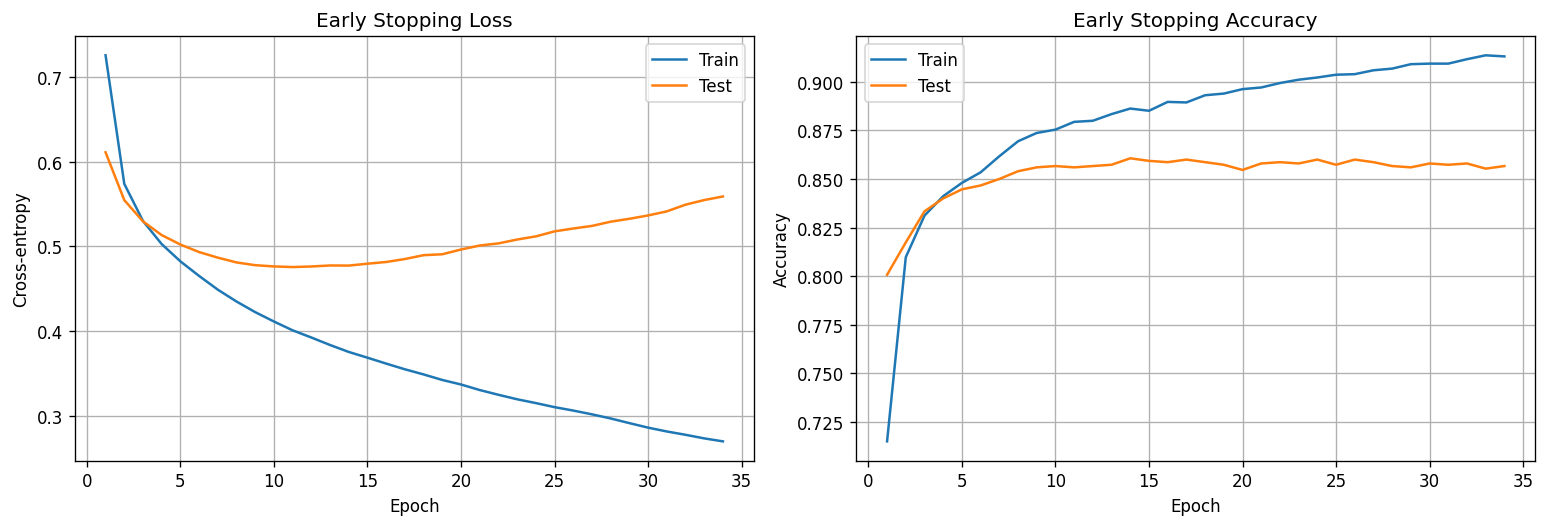

Used min_delta = 1e-3, patience = 20
Epochs completed: 34
Best restored test accuracy: 0.8606666646003723
Previous 3.2.4 baseline test accuracy: 0.8306666665077209


In [18]:
# ============================================================
# Problem 3.2.5
# Early stopping for the baseline model
# ============================================================

baseline_es_cfg = dataclasses.replace(
    classification_cfg_template,
    epochs=200,
    dropout=0.0,
 )
baseline_es_dm = DataModule.from_splits(
    baseline_es_cfg,
    Xtr=X_cls_train,
    Xte=X_cls_test,
    ytr=y_cls_train,
    yte=y_cls_test,
 )
baseline_es_model = Model(
    baseline_es_cfg,
    baseline_es_dm,
    make_mlp_network,
    softmax_loss_and_metrics,
 )

baseline_es_history = baseline_es_model.fit(
    min_delta=1e-3,
    patience=20,
    monitor="val_acc",
    mode="max",
    restore_best=True,
    verbose=False,
 )
baseline_es_metrics = baseline_es_model.evaluate()

epochs_es = np.arange(1, len(baseline_es_history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_es, baseline_es_history["loss"], label="Train")
axes[0].plot(epochs_es, baseline_es_history["val_loss"], label="Test")
axes[0].set_title("Early Stopping Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_es, baseline_es_history["acc"], label="Train")
axes[1].plot(epochs_es, baseline_es_history["val_acc"], label="Test")
axes[1].set_title("Early Stopping Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Used min_delta = 1e-3, patience = 20")
print("Epochs completed:", len(baseline_es_history["loss"]))
print("Best restored test accuracy:", baseline_es_metrics["acc"])
print("Previous 3.2.4 baseline test accuracy:", baseline_history["val_acc"][-1])

## Results — 3.2.5

Results: 

## 3.2.6

Task: Revisit California Housing dataset and achieve MAE < 0.35 on T_test.

---

Final California Housing test MAE: 0.349413126707077
Target: MAE < 0.35
Network hidden layers: (256, 256, 128)
Optimizer: adamw lr= 0.001


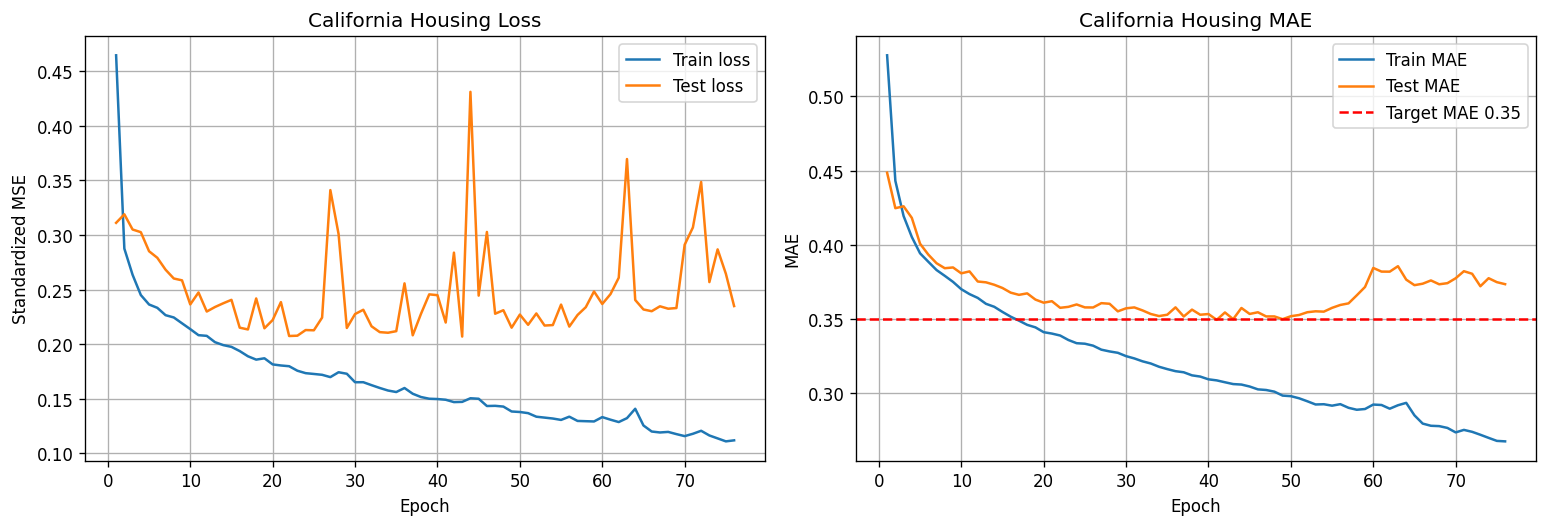

In [20]:
# ============================================================
# Problem 3.2.6
# California Housing regression with MAE evaluation
# ============================================================

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_california = housing.data.astype(np.float32)
y_california = housing.target.astype(np.float32)

X_cal_train_raw, X_cal_test_raw, y_cal_train_raw, y_cal_test_raw = train_test_split(
    X_california,
    y_california,
    test_size=0.2,
    random_state=0,
 )

x_scaler_cal = StandardScaler()
X_cal_train = x_scaler_cal.fit_transform(X_cal_train_raw).astype(np.float32)
X_cal_test = x_scaler_cal.transform(X_cal_test_raw).astype(np.float32)

y_cal_mean = float(y_cal_train_raw.mean())
y_cal_std = float(y_cal_train_raw.std() + 1e-8)
y_cal_train = ((y_cal_train_raw - y_cal_mean) / y_cal_std).astype(np.float32).reshape(-1, 1)
y_cal_test = ((y_cal_test_raw - y_cal_mean) / y_cal_std).astype(np.float32).reshape(-1, 1)


def california_loss_and_metrics(outputs: Array, y: Array, mask: Array) -> Tuple[Array, Metrics]:
    preds_std = outputs.squeeze(-1)
    targets_std = y.squeeze(-1)
    mask = mask.astype(jnp.float32)

    valid_batch_size = jnp.maximum(jnp.sum(mask), 1.0)
    mse = jnp.sum(((preds_std - targets_std) ** 2) * mask) / valid_batch_size

    preds = preds_std * y_cal_std + y_cal_mean
    targets = targets_std * y_cal_std + y_cal_mean
    mae = jnp.sum(jnp.abs(preds - targets) * mask) / valid_batch_size

    return mse, {"loss": mse, "mae": mae}


california_datacfg = DataConfig(
    seed=0,
    batch_size=256,
    test_batch_size=512,
    test_size=0.2,
    shuffle_train=True,
 )
california_cfg = Config(
    seed=0,
    epochs=250,
    lr=1e-3,
    optim="adamw",
    weight_decay=1e-5,
    clip_norm=1.0,
    in_dim=X_cal_train.shape[1],
    hidden_dims=(256, 256, 128),
    out_dim=1,
    dropout=0.0,
    data=california_datacfg,
 )

california_dm = DataModule.from_splits(
    california_cfg,
    Xtr=X_cal_train,
    Xte=X_cal_test,
    ytr=y_cal_train,
    yte=y_cal_test,
 )
california_model = Model(
    california_cfg,
    california_dm,
    make_mlp_network,
    california_loss_and_metrics,
 )

california_history = california_model.fit(
    min_delta=5e-4,
    patience=35,
    monitor="val_mae",
    mode="min",
    restore_best=True,
    verbose=False,
 )

california_pred_std = california_model.predict(X_cal_test).squeeze()
california_pred = california_pred_std * y_cal_std + y_cal_mean
california_mae = mean_absolute_error(y_cal_test_raw, california_pred)

print("Final California Housing test MAE:", california_mae)
print("Target: MAE < 0.35")
print("Network hidden layers:", california_cfg.hidden_dims)
print("Optimizer:", california_cfg.optim, "lr=", california_cfg.lr)

epochs_cal = np.arange(1, len(california_history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_cal, california_history["loss"], label="Train loss")
axes[0].plot(epochs_cal, california_history["val_loss"], label="Test loss")
axes[0].set_title("California Housing Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Standardized MSE")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_cal, california_history["mae"], label="Train MAE")
axes[1].plot(epochs_cal, california_history["val_mae"], label="Test MAE")
axes[1].axhline(0.35, color="red", linestyle="--", label="Target MAE 0.35")
axes[1].set_title("California Housing MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Results — 3.2.6

Results: 

# Problem 3.3 (25%)

Probabilistic outputs and uncertainty estimation. Use Flax/NNX skeleton.

## Implementation guideline (mandatory)

Use `problem_skeleton_flax_keras_like.py` and the listed components.

---

## 3.3.1

Task: Expand loss J_y and derive gradients. (No solutions here.)

---

## Results — 3.3.1

In the report

## 3.3.2

Task: Fit a deterministic model to `data_uncertainty` and provide plots. 

---

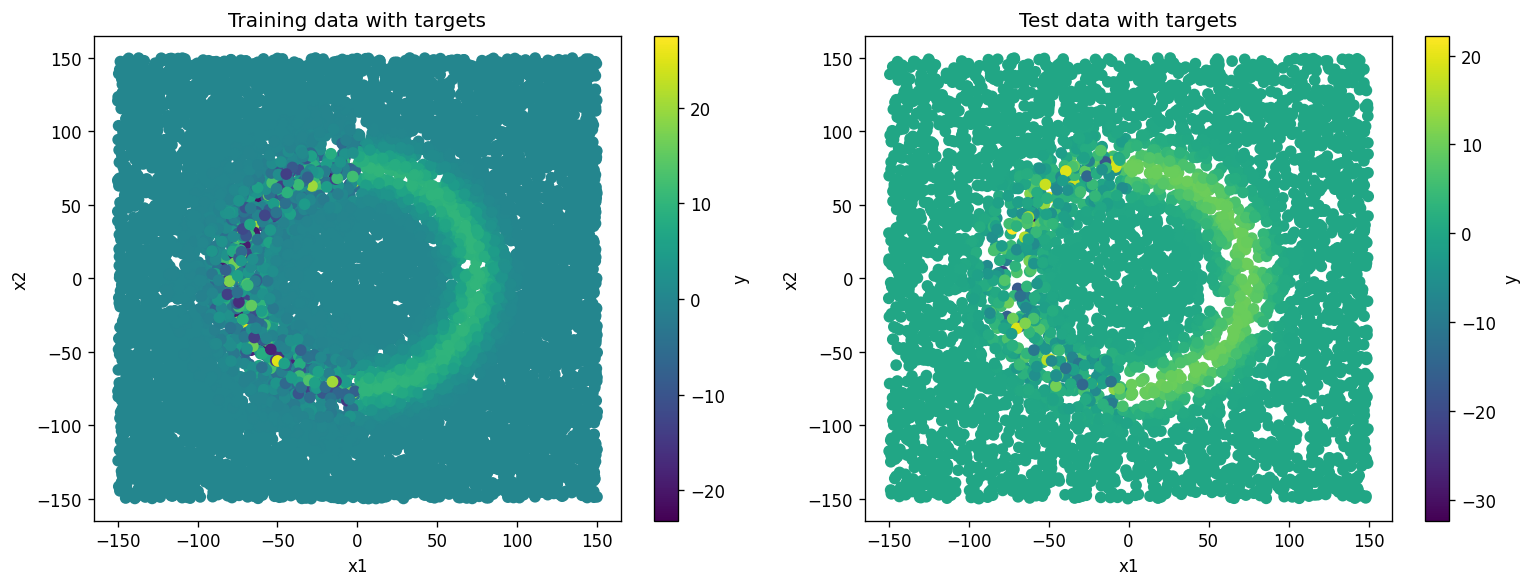

Deterministic test MSE: 3.7701756954193115


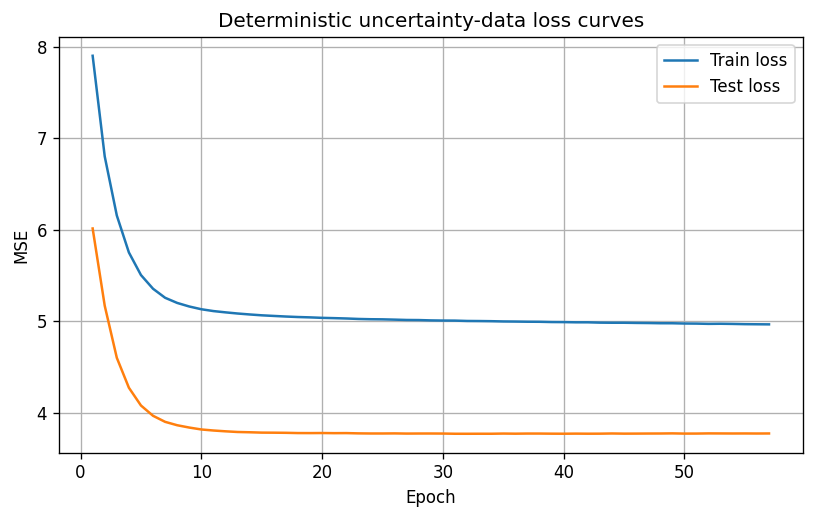

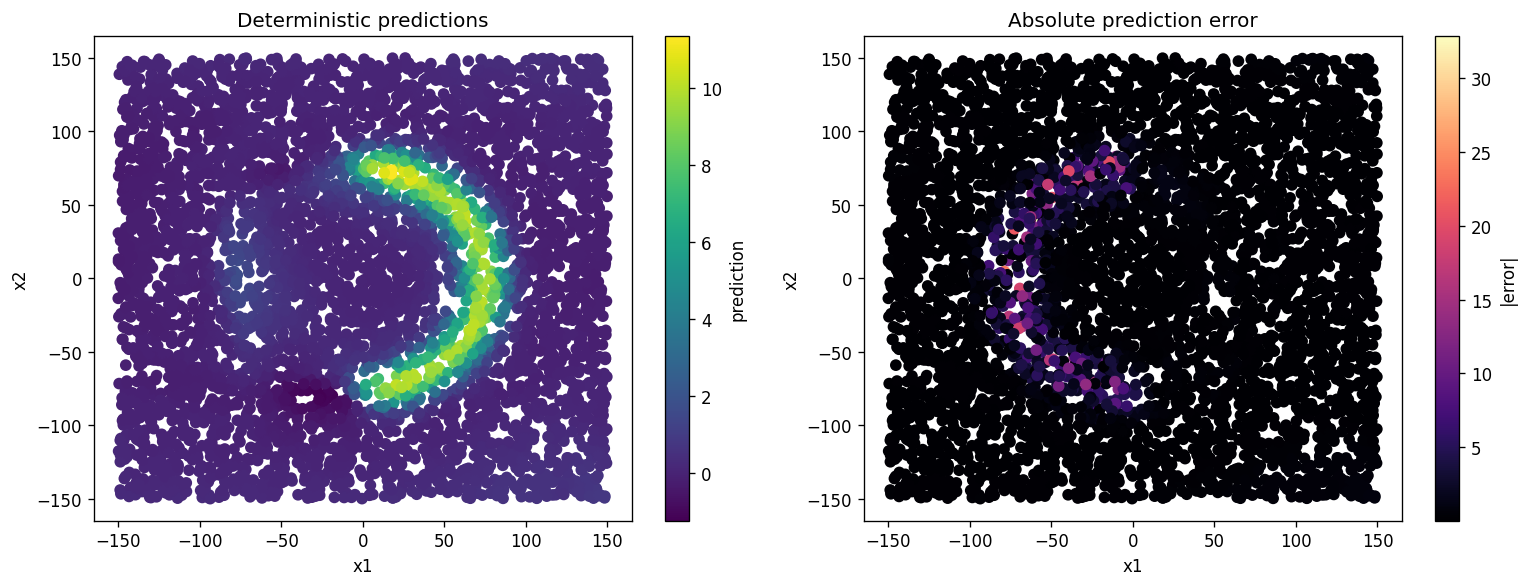

In [14]:
# ============================================================
# Problem 3.3.2
# Deterministic regression on data_uncertainty
# ============================================================

from pathlib import Path
from sklearn.metrics import mean_squared_error
import zipfile

uncertainty_extract_dir = Path("data_uncertainty_extracted")
if not uncertainty_extract_dir.exists():
    with zipfile.ZipFile("data_uncertainty.zip", "r") as zf:
        zf.extractall(uncertainty_extract_dir)

uncertainty_data_dir = uncertainty_extract_dir / "data"


def read_numeric_csv(path: Path) -> np.ndarray:
    frame = pd.read_csv(path)
    unnamed_cols = [col for col in frame.columns if str(col).startswith("Unnamed")]
    if unnamed_cols:
        frame = frame.drop(columns=unnamed_cols)
    return frame.to_numpy(dtype=np.float32)


unc_X_train = read_numeric_csv(uncertainty_data_dir / "X_train.csv")
unc_X_test = read_numeric_csv(uncertainty_data_dir / "X_test.csv")
unc_X_train_coords = read_numeric_csv(uncertainty_data_dir / "X_train_coords.csv")
unc_X_test_coords = read_numeric_csv(uncertainty_data_dir / "X_test_coords.csv")
unc_y_train = read_numeric_csv(uncertainty_data_dir / "y_train.csv").reshape(-1, 1)
unc_y_test = read_numeric_csv(uncertainty_data_dir / "y_test.csv").reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
train_plot = axes[0].scatter(unc_X_train_coords[:, 0], unc_X_train_coords[:, 1], c=unc_y_train.squeeze(), cmap="viridis")
axes[0].set_title("Training data with targets")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(train_plot, ax=axes[0], label="y")

test_plot = axes[1].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=unc_y_test.squeeze(), cmap="viridis")
axes[1].set_title("Test data with targets")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
fig.colorbar(test_plot, ax=axes[1], label="y")
plt.tight_layout()
plt.show()


def uncertainty_mse_loss_and_metrics(outputs: Array, y: Array, mask: Array) -> Tuple[Array, Metrics]:
    preds = outputs.squeeze(-1)
    targets = y.squeeze(-1)
    mask = mask.astype(jnp.float32)

    valid_batch_size = jnp.maximum(jnp.sum(mask), 1.0)
    mse = jnp.sum(((preds - targets) ** 2) * mask) / valid_batch_size

    return mse, {"loss": mse, "mse": mse}


uncertainty_datacfg = DataConfig(
    seed=0,
    batch_size=128,
    test_batch_size=256,
    test_size=0.2,
    shuffle_train=True,
 )
uncertainty_det_cfg = Config(
    seed=0,
    epochs=200,
    lr=1e-3,
    optim="adam",
    in_dim=unc_X_train.shape[1],
    hidden_dims=(128, 128),
    out_dim=1,
    dropout=0.0,
    data=uncertainty_datacfg,
 )
uncertainty_det_dm = DataModule.from_splits(
    uncertainty_det_cfg,
    Xtr=unc_X_train,
    Xte=unc_X_test,
    ytr=unc_y_train,
    yte=unc_y_test,
 )
uncertainty_det_model = Model(
    uncertainty_det_cfg,
    uncertainty_det_dm,
    make_mlp_network,
    uncertainty_mse_loss_and_metrics,
 )

uncertainty_det_history = uncertainty_det_model.fit(
    min_delta=1e-5,
    patience=25,
    monitor="val_loss",
    mode="min",
    restore_best=True,
    verbose=False,
 )

uncertainty_det_pred = uncertainty_det_model.predict(unc_X_test).squeeze()
uncertainty_det_abs_error = np.abs(uncertainty_det_pred - unc_y_test.squeeze())
uncertainty_det_mse = mean_squared_error(unc_y_test.squeeze(), uncertainty_det_pred)
print("Deterministic test MSE:", uncertainty_det_mse)

epochs_unc = np.arange(1, len(uncertainty_det_history["loss"]) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_unc, uncertainty_det_history["loss"], label="Train loss")
plt.plot(epochs_unc, uncertainty_det_history["val_loss"], label="Test loss")
plt.title("Deterministic uncertainty-data loss curves")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pred_plot = axes[0].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=uncertainty_det_pred, cmap="viridis")
axes[0].set_title("Deterministic predictions")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(pred_plot, ax=axes[0], label="prediction")

err_plot = axes[1].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=uncertainty_det_abs_error, cmap="magma")
axes[1].set_title("Absolute prediction error")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
fig.colorbar(err_plot, ax=axes[1], label="|error|")
plt.tight_layout()
plt.show()

## Results — 3.3.2

Results:

## 3.3.3

Task: Extend to probabilistic output producing mu and sigma. 

---

In [15]:
# ============================================================
# Problem 3.3.3
# Extend to probabilistic outputs producing mu and sigma
# ============================================================


def gaussian_nll_and_metrics(outputs: Array, y: Array, mask: Array) -> Tuple[Array, Metrics]:
    mu = outputs[:, 0]
    log_var = jnp.clip(outputs[:, 1], -8.0, 6.0)
    sigma = jnp.exp(0.5 * log_var)

    targets = y.squeeze(-1)
    mask = mask.astype(jnp.float32)
    valid_batch_size = jnp.maximum(jnp.sum(mask), 1.0)

    nll = 0.5 * jnp.log(2.0 * jnp.pi) + 0.5 * log_var + 0.5 * ((targets - mu) ** 2) * jnp.exp(-log_var)
    loss = jnp.sum(nll * mask) / valid_batch_size
    mse = jnp.sum(((targets - mu) ** 2) * mask) / valid_batch_size
    sigma_metric = jnp.sum(sigma * mask) / valid_batch_size

    return loss, {"loss": loss, "mse": mse, "sigma": sigma_metric}


uncertainty_prob_cfg = Config(
    seed=0,
    epochs=200,
    lr=1e-3,
    optim="adam",
    in_dim=unc_X_train.shape[1],
    hidden_dims=(128, 128),
    out_dim=2,
    dropout=0.0,
    data=uncertainty_datacfg,
 )
uncertainty_prob_dm = DataModule.from_splits(
    uncertainty_prob_cfg,
    Xtr=unc_X_train,
    Xte=unc_X_test,
    ytr=unc_y_train,
    yte=unc_y_test,
 )
uncertainty_prob_model = Model(
    uncertainty_prob_cfg,
    uncertainty_prob_dm,
    make_probabilistic_network,
    gaussian_nll_and_metrics,
 )

sample_prob_outputs = make_probabilistic_network(uncertainty_prob_cfg, nnx.Rngs(0))(jnp.asarray(unc_X_test[:5]))
print("Probabilistic output shape (mu, log_var):", sample_prob_outputs.shape)

Probabilistic output shape (mu, log_var): (5, 2)


## Results — 3.3.3

Results: 

## 3.3.4

Task: Fit probabilistic model and provide metrics and visualizations.

---

Probabilistic test MSE: 3.8097496
Average predicted sigma: 0.6463057
Deterministic 3.3.2 test MSE: 3.7701756954193115


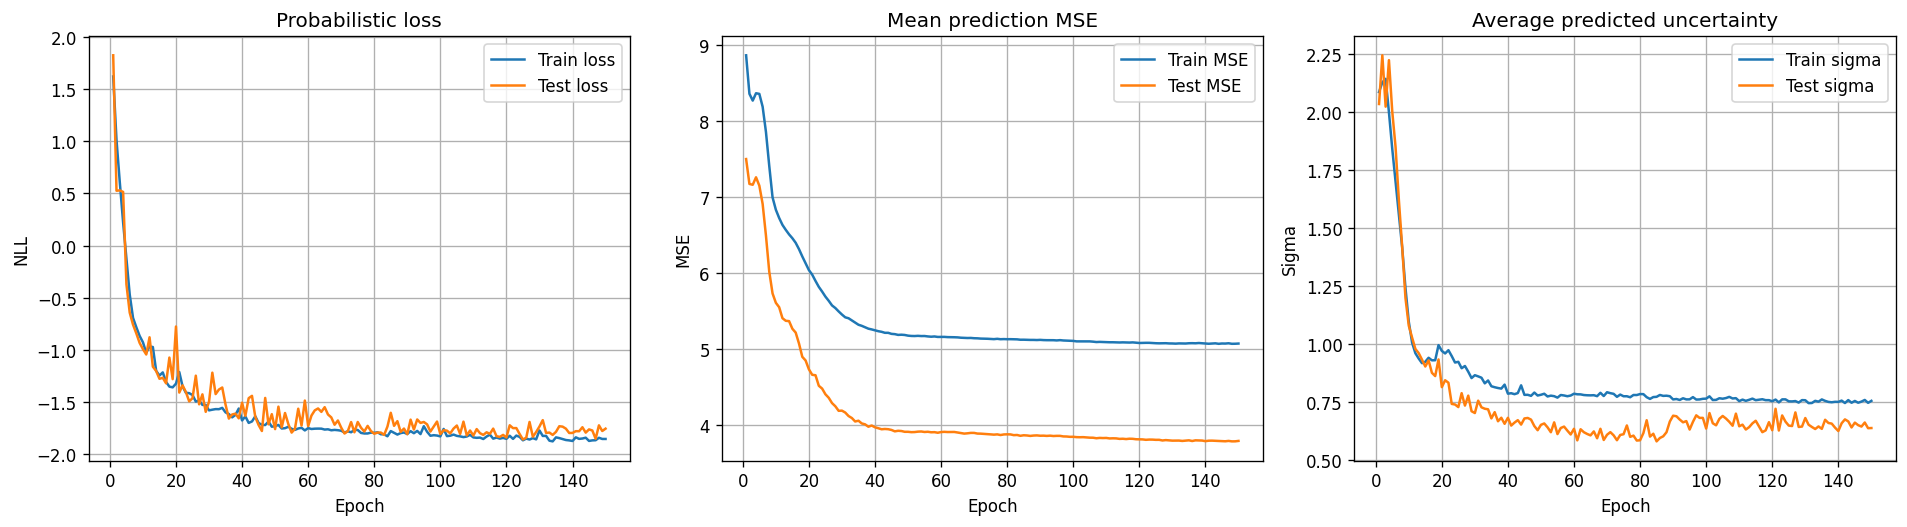

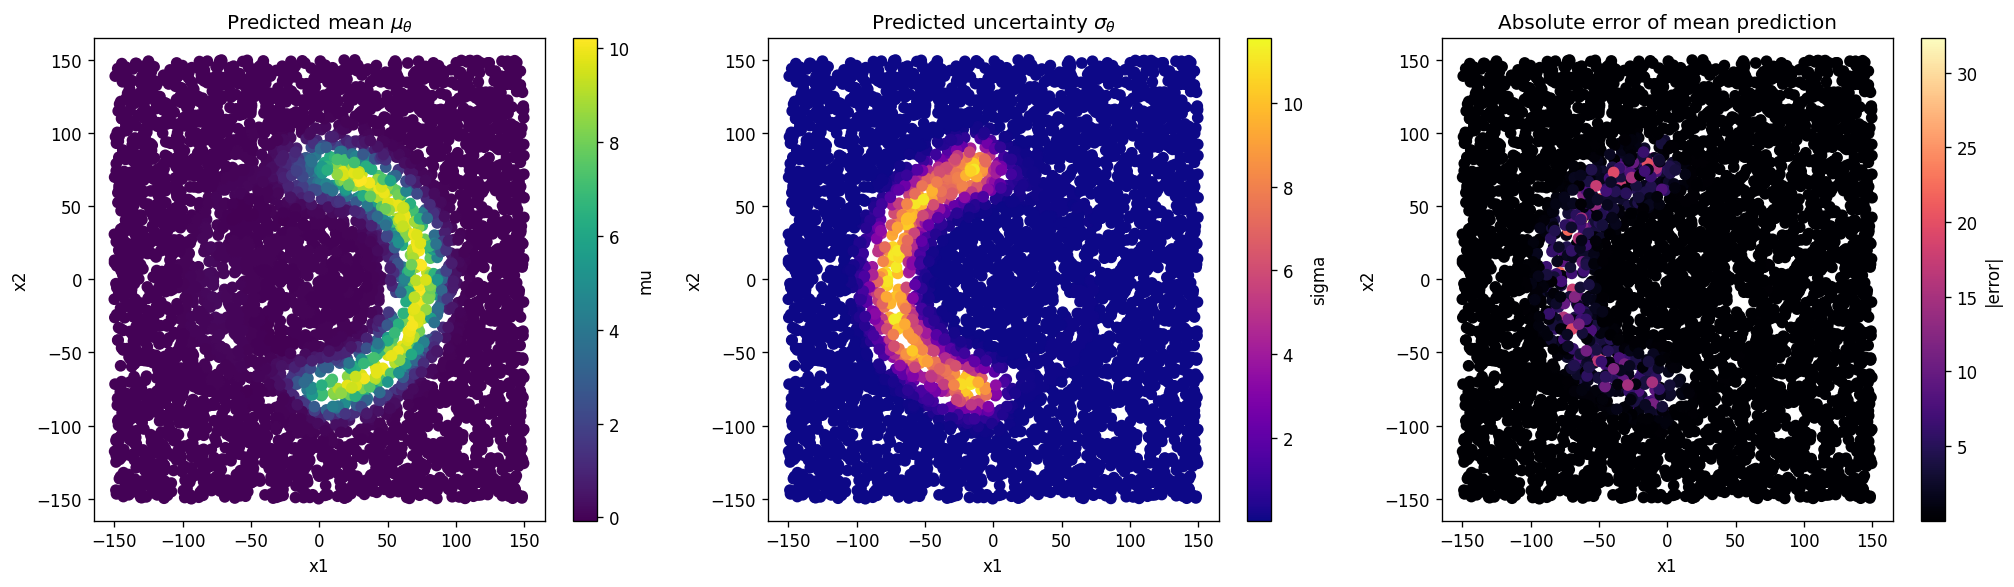

Interpretation:
Large predicted sigma should appear in regions where the target is harder to predict.
A useful probabilistic model shows higher sigma where the absolute error also tends to be larger.


In [17]:
# ============================================================
# Problem 3.3.4
# Train probabilistic model + visualize uncertainty
# ============================================================

uncertainty_prob_history = uncertainty_prob_model.fit(
    min_delta=1e-5,
    patience=25,
    monitor="val_loss",
    mode="min",
    restore_best=True,
    verbose=False,
 )

uncertainty_prob_outputs = uncertainty_prob_model.predict(unc_X_test)
unc_mu_pred = np.asarray(uncertainty_prob_outputs[:, 0])
unc_log_var_pred = np.clip(np.asarray(uncertainty_prob_outputs[:, 1]), -8.0, 6.0)
unc_sigma_pred = np.exp(0.5 * unc_log_var_pred)
unc_prob_abs_error = np.abs(unc_mu_pred - unc_y_test.squeeze())
uncertainty_prob_mse = np.mean((unc_mu_pred - unc_y_test.squeeze()) ** 2)

print("Probabilistic test MSE:", uncertainty_prob_mse)
print("Average predicted sigma:", unc_sigma_pred.mean())
print("Deterministic 3.3.2 test MSE:", uncertainty_det_mse)

epochs_prob = np.arange(1, len(uncertainty_prob_history["loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epochs_prob, uncertainty_prob_history["loss"], label="Train loss")
axes[0].plot(epochs_prob, uncertainty_prob_history["val_loss"], label="Test loss")
axes[0].set_title("Probabilistic loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_prob, uncertainty_prob_history["mse"], label="Train MSE")
axes[1].plot(epochs_prob, uncertainty_prob_history["val_mse"], label="Test MSE")
axes[1].set_title("Mean prediction MSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(epochs_prob, uncertainty_prob_history["sigma"], label="Train sigma")
axes[2].plot(epochs_prob, uncertainty_prob_history["val_sigma"], label="Test sigma")
axes[2].set_title("Average predicted uncertainty")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Sigma")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
mu_plot = axes[0].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=unc_mu_pred, cmap="viridis")
axes[0].set_title("Predicted mean $\\mu_\\theta$")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(mu_plot, ax=axes[0], label="mu")

sigma_plot = axes[1].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=unc_sigma_pred, cmap="plasma")
axes[1].set_title("Predicted uncertainty $\\sigma_\\theta$")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
fig.colorbar(sigma_plot, ax=axes[1], label="sigma")

err_plot = axes[2].scatter(unc_X_test_coords[:, 0], unc_X_test_coords[:, 1], c=unc_prob_abs_error, cmap="magma")
axes[2].set_title("Absolute error of mean prediction")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")
fig.colorbar(err_plot, ax=axes[2], label="|error|")

plt.tight_layout()
plt.show()

print("Interpretation:")
print("Large predicted sigma should appear in regions where the target is harder to predict.")
print("A useful probabilistic model shows higher sigma where the absolute error also tends to be larger.")

## Results — 3.3.4

Results: 

## 3.3.5

Task: Apply probabilistic model to California Housing dataset and compute correlations. 

---

Deterministic 3.2.6 MAE: 0.349413126707077
Probabilistic model MAE: 0.3374253511428833
Correlation(|error|, sigma): 0.22013090311438088

Sigma-threshold MAE results:
quantile=0.25 | sigma<= 0.1707 | subset size=1032 | subset MAE=0.1649
quantile=0.50 | sigma<= 0.2780 | subset size=2064 | subset MAE=0.2118
quantile=0.75 | sigma<= 0.4236 | subset size=3096 | subset MAE=0.2645
quantile=0.90 | sigma<= 0.5770 | subset size=3715 | subset MAE=0.2953


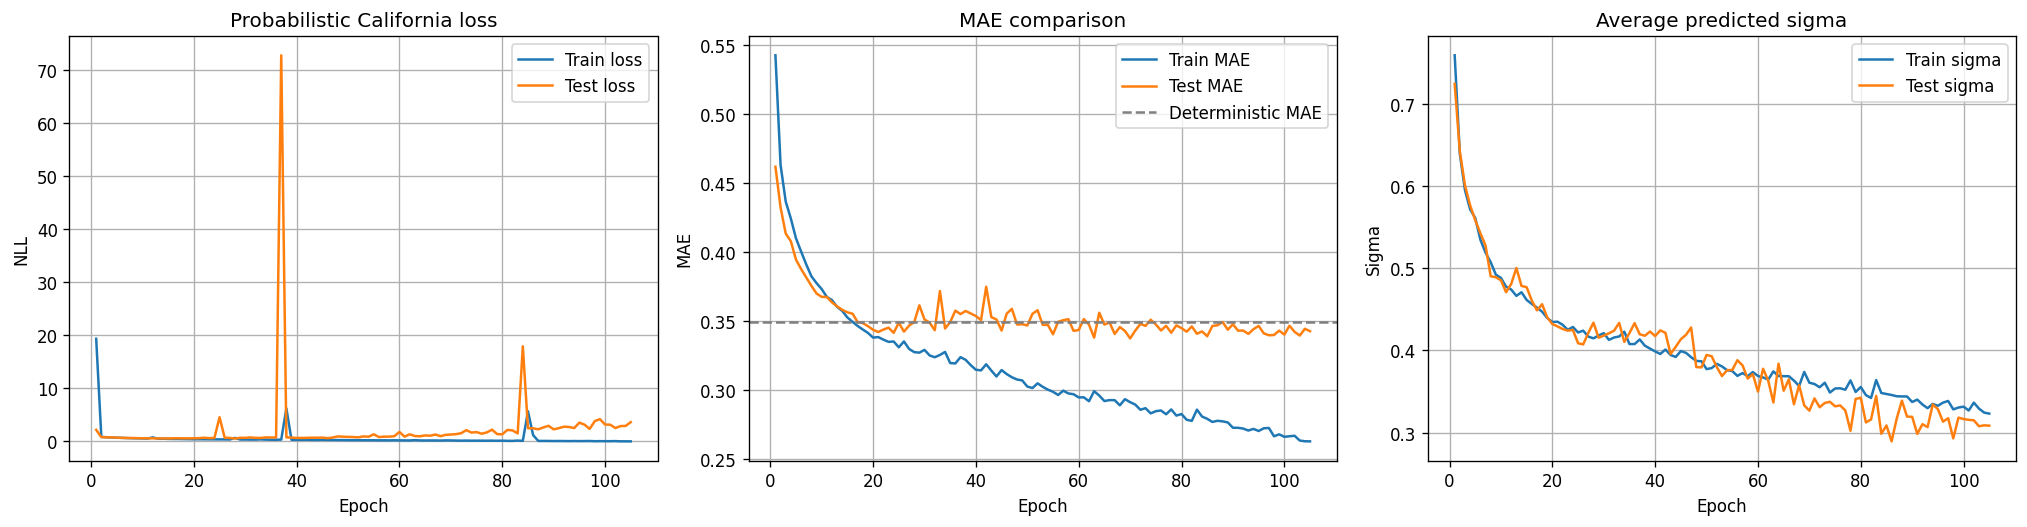

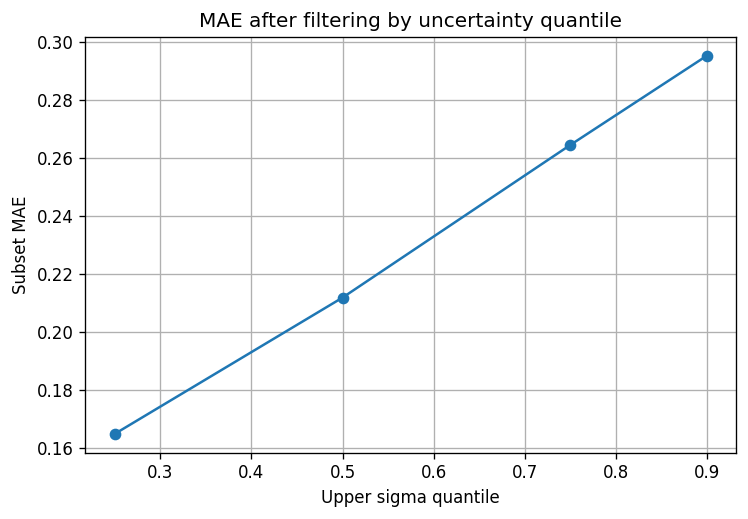

In [21]:
# ============================================================
# Problem 3.3.5
# Probabilistic California Housing + uncertainty filtering
# ============================================================


def california_gaussian_nll_and_metrics(outputs: Array, y: Array, mask: Array) -> Tuple[Array, Metrics]:
    mu_std = outputs[:, 0]
    log_var = jnp.clip(outputs[:, 1], -8.0, 6.0)
    sigma_std = jnp.exp(0.5 * log_var)

    targets_std = y.squeeze(-1)
    mask = mask.astype(jnp.float32)
    valid_batch_size = jnp.maximum(jnp.sum(mask), 1.0)

    nll = 0.5 * jnp.log(2.0 * jnp.pi) + 0.5 * log_var + 0.5 * ((targets_std - mu_std) ** 2) * jnp.exp(-log_var)
    loss = jnp.sum(nll * mask) / valid_batch_size

    mu = mu_std * y_cal_std + y_cal_mean
    targets = targets_std * y_cal_std + y_cal_mean
    sigma = sigma_std * y_cal_std

    mae = jnp.sum(jnp.abs(mu - targets) * mask) / valid_batch_size
    mse = jnp.sum(((mu - targets) ** 2) * mask) / valid_batch_size
    sigma_metric = jnp.sum(sigma * mask) / valid_batch_size

    return loss, {"loss": loss, "mae": mae, "mse": mse, "sigma": sigma_metric}


california_prob_cfg = Config(
    seed=0,
    epochs=250,
    lr=1e-3,
    optim="adamw",
    weight_decay=1e-5,
    clip_norm=1.0,
    in_dim=X_cal_train.shape[1],
    hidden_dims=(256, 256, 128),
    out_dim=2,
    dropout=0.0,
    data=california_datacfg,
 )
california_prob_dm = DataModule.from_splits(
    california_prob_cfg,
    Xtr=X_cal_train,
    Xte=X_cal_test,
    ytr=y_cal_train,
    yte=y_cal_test,
 )
california_prob_model = Model(
    california_prob_cfg,
    california_prob_dm,
    make_probabilistic_network,
    california_gaussian_nll_and_metrics,
 )

california_prob_history = california_prob_model.fit(
    min_delta=5e-4,
    patience=35,
    monitor="val_mae",
    mode="min",
    restore_best=True,
    verbose=False,
 )

california_prob_outputs = california_prob_model.predict(X_cal_test)
california_prob_mu_std = np.asarray(california_prob_outputs[:, 0])
california_prob_log_var = np.clip(np.asarray(california_prob_outputs[:, 1]), -8.0, 6.0)
california_prob_sigma = np.exp(0.5 * california_prob_log_var) * y_cal_std
california_prob_pred = california_prob_mu_std * y_cal_std + y_cal_mean

california_prob_mae = mean_absolute_error(y_cal_test_raw, california_prob_pred)
california_abs_error = np.abs(california_prob_pred - y_cal_test_raw)
california_sigma_error_corr = np.corrcoef(california_abs_error, california_prob_sigma)[0, 1]

quantile_levels = [0.25, 0.5, 0.75, 0.9]
sigma_threshold_results = []
for level in quantile_levels:
    threshold = float(np.quantile(california_prob_sigma, level))
    selected = california_prob_sigma <= threshold
    subset_mae = float(mean_absolute_error(y_cal_test_raw[selected], california_prob_pred[selected]))
    sigma_threshold_results.append((level, threshold, subset_mae, int(selected.sum())))

print("Deterministic 3.2.6 MAE:", california_mae)
print("Probabilistic model MAE:", california_prob_mae)
print("Correlation(|error|, sigma):", california_sigma_error_corr)
print()
print("Sigma-threshold MAE results:")
for level, threshold, subset_mae, count in sigma_threshold_results:
    print(f"quantile={level:.2f} | sigma<= {threshold:.4f} | subset size={count} | subset MAE={subset_mae:.4f}")

epochs_cal_prob = np.arange(1, len(california_prob_history["loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(epochs_cal_prob, california_prob_history["loss"], label="Train loss")
axes[0].plot(epochs_cal_prob, california_prob_history["val_loss"], label="Test loss")
axes[0].set_title("Probabilistic California loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs_cal_prob, california_prob_history["mae"], label="Train MAE")
axes[1].plot(epochs_cal_prob, california_prob_history["val_mae"], label="Test MAE")
axes[1].axhline(california_mae, color="gray", linestyle="--", label="Deterministic MAE")
axes[1].set_title("MAE comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(epochs_cal_prob, california_prob_history["sigma"], label="Train sigma")
axes[2].plot(epochs_cal_prob, california_prob_history["val_sigma"], label="Test sigma")
axes[2].set_title("Average predicted sigma")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Sigma")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(
    [level for level, _, _, _ in sigma_threshold_results],
    [subset_mae for _, _, subset_mae, _ in sigma_threshold_results],
    marker="o",
 )
plt.title("MAE after filtering by uncertainty quantile")
plt.xlabel("Upper sigma quantile")
plt.ylabel("Subset MAE")
plt.grid(True)
plt.show()

## Results — 3.3.5

Results: 

# Problem 3.4 (25%)

Gradient boosting and ensemble methods.

## 3.4.1

Task: Show negative gradient relates to residuals for squared loss. (No solutions here.)

---

## Results — 3.4.1

In the report

## 3.4.2

Task: Implement gradient boosting regressor using DecisionTreeRegressor(max_depth=1) as weak learners and visualize results. (No solutions here.)

---



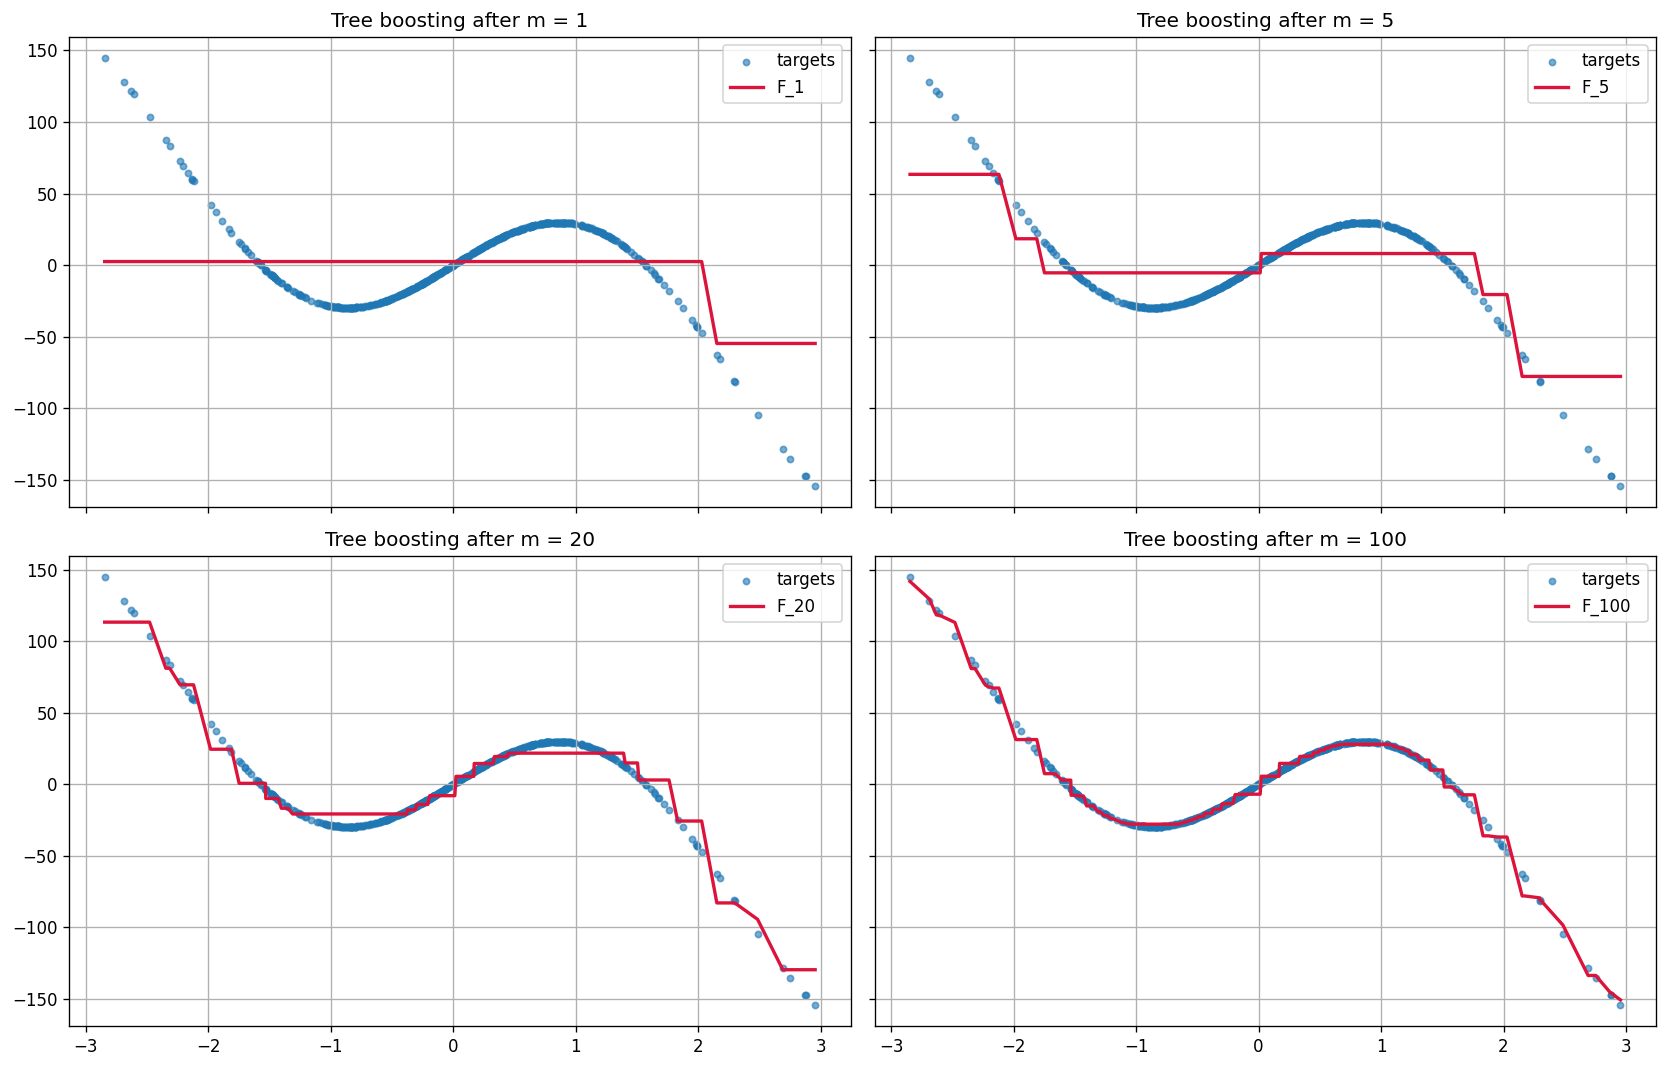

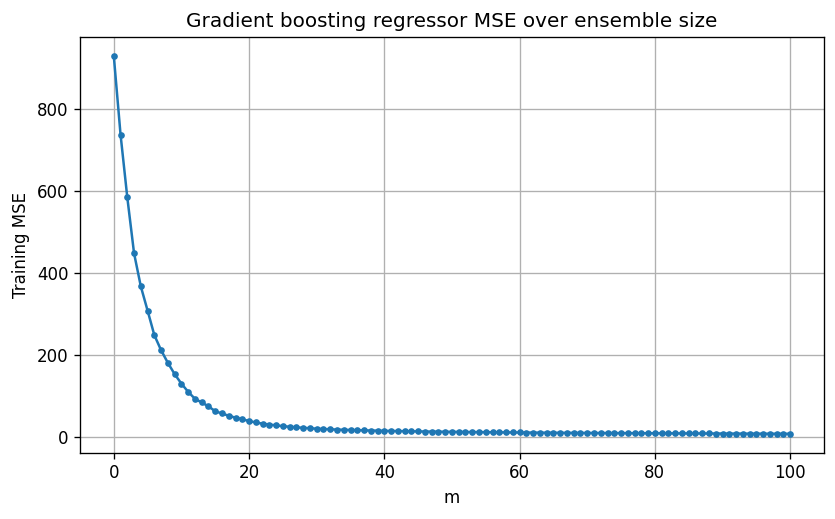

Final regression MSE with tree weak learners: 6.863802648147294


In [16]:
# ============================================================
# Problem 3.4.2
# Gradient boosting regressor with arbitrary sklearn weak learners
# ============================================================

from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
from sklearn.tree import DecisionTreeRegressor


def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-x))


class GradientBoostingRegressorScratch:
    def __init__(self, base_estimator, n_estimators: int = 100, learning_rate: float = 0.5):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float64).reshape(-1)

        self.init_mean_ = float(np.mean(y))
        self.estimators_ = []
        self.train_mse_ = [mean_squared_error(y, np.full_like(y, self.init_mean_))]

        current_pred = np.full_like(y, self.init_mean_, dtype=np.float64)
        for _ in range(self.n_estimators):
            residual = y - current_pred
            estimator = clone(self.base_estimator)
            estimator.fit(X, residual)
            current_pred = current_pred + self.learning_rate * estimator.predict(X)
            self.estimators_.append(estimator)
            self.train_mse_.append(mean_squared_error(y, current_pred))

        return self

    def predict(self, X: np.ndarray, n_estimators: Optional[int] = None) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        pred = np.full(X.shape[0], self.init_mean_, dtype=np.float64)
        use_estimators = self.estimators_ if n_estimators is None else self.estimators_[:n_estimators]
        for estimator in use_estimators:
            pred = pred + self.learning_rate * estimator.predict(X)
        return pred


class GradientBoostingBinaryClassifierScratch:
    def __init__(self, base_estimator, n_estimators: int = 1000, learning_rate: float = 0.5, initial_score: float = 0.0):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.initial_score = initial_score

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int32).reshape(-1)

        self.estimators_ = []
        self.train_accuracy_ = []
        self.train_log_loss_ = []

        current_score = np.full(X.shape[0], self.initial_score, dtype=np.float64)
        self.train_accuracy_.append(accuracy_score(y, (sigmoid(current_score) >= 0.5).astype(int)))
        self.train_log_loss_.append(log_loss(y, sigmoid(current_score), labels=[0, 1]))

        for _ in range(self.n_estimators):
            residual = y - sigmoid(current_score)
            estimator = clone(self.base_estimator)
            estimator.fit(X, residual)
            current_score = current_score + self.learning_rate * estimator.predict(X)
            self.estimators_.append(estimator)
            probs = sigmoid(current_score)
            self.train_accuracy_.append(accuracy_score(y, (probs >= 0.5).astype(int)))
            self.train_log_loss_.append(log_loss(y, probs, labels=[0, 1]))

        return self

    def decision_function(self, X: np.ndarray, n_estimators: Optional[int] = None) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        score = np.full(X.shape[0], self.initial_score, dtype=np.float64)
        use_estimators = self.estimators_ if n_estimators is None else self.estimators_[:n_estimators]
        for estimator in use_estimators:
            score = score + self.learning_rate * estimator.predict(X)
        return score

    def predict_proba(self, X: np.ndarray, n_estimators: Optional[int] = None) -> np.ndarray:
        probs_pos = sigmoid(self.decision_function(X, n_estimators=n_estimators))
        return np.column_stack([1.0 - probs_pos, probs_pos])

    def predict(self, X: np.ndarray, n_estimators: Optional[int] = None) -> np.ndarray:
        return (self.predict_proba(X, n_estimators=n_estimators)[:, 1] >= 0.5).astype(int)


gb_reg_df = pd.read_csv("gradient_boosting_regression.csv")
unnamed_cols = [col for col in gb_reg_df.columns if str(col).startswith("Unnamed")]
if unnamed_cols:
    gb_reg_df = gb_reg_df.drop(columns=unnamed_cols)

X_gb_reg = gb_reg_df[["x"]].to_numpy(dtype=np.float32)
y_gb_reg = gb_reg_df["y"].to_numpy(dtype=np.float64)

tree_boost_reg = GradientBoostingRegressorScratch(
    base_estimator=DecisionTreeRegressor(max_depth=1, random_state=0),
    n_estimators=100,
    learning_rate=0.5,
 )
tree_boost_reg.fit(X_gb_reg, y_gb_reg)

x_order = np.argsort(X_gb_reg[:, 0])
m_values = [1, 5, 20, 100]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, m in zip(axes.flat, m_values):
    pred_m = tree_boost_reg.predict(X_gb_reg, n_estimators=m)
    axis.scatter(X_gb_reg[:, 0], y_gb_reg, s=14, alpha=0.6, label="targets")
    axis.plot(X_gb_reg[x_order, 0], pred_m[x_order], color="crimson", linewidth=2, label=f"F_{m}")
    axis.set_title(f"Tree boosting after m = {m}")
    axis.grid(True)
    axis.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(0, 101), tree_boost_reg.train_mse_, marker="o", markersize=3)
plt.title("Gradient boosting regressor MSE over ensemble size")
plt.xlabel("m")
plt.ylabel("Training MSE")
plt.grid(True)
plt.show()

print("Final regression MSE with tree weak learners:", tree_boost_reg.train_mse_[-1])

## Results — 3.4.2

Results:



## 3.4.3

Switch the `DecisionTreeRegressor` for a `LinearRegression` scheme and compare the obtained ensemble to the results from Task 3.4.2.

Discuss whether a linear model is a reasonable choice for a boosting algorithm.

---


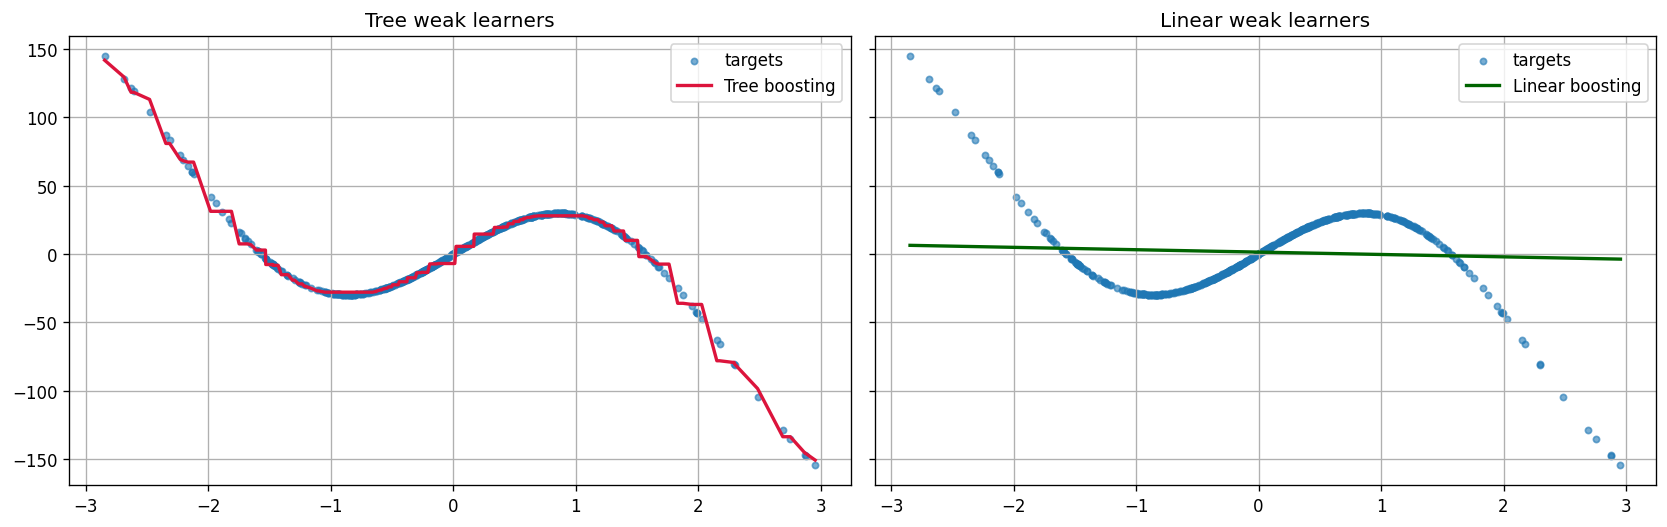

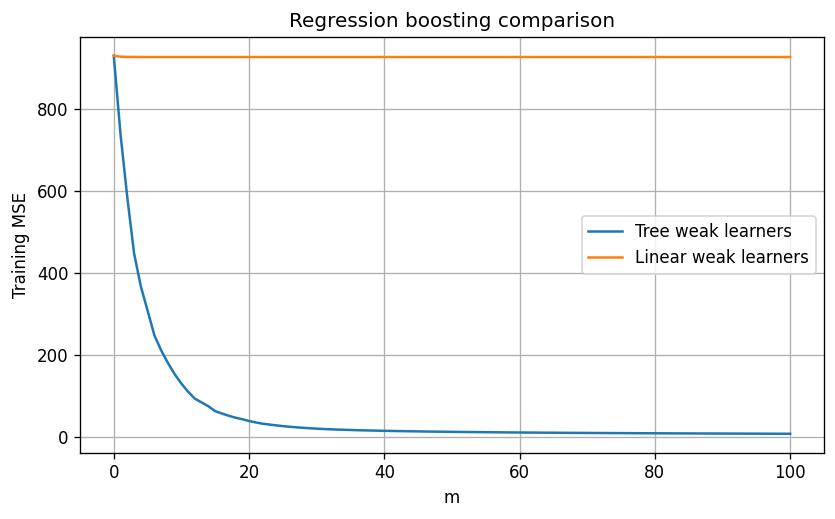

Tree final MSE: 6.863802648147294
Linear final MSE: 927.6935255642305

Discussion:
Linear weak learners are often too rigid for stage-wise residual fitting on nonlinear data.
Tree stumps adapt locally, so they usually capture curved residual structure better.


In [22]:
# ============================================================
# Problem 3.4.3
# Replace tree stumps with LinearRegression weak learners
# ============================================================

linear_boost_reg = GradientBoostingRegressorScratch(
    base_estimator=LinearRegression(),
    n_estimators=100,
    learning_rate=0.5,
 )
linear_boost_reg.fit(X_gb_reg, y_gb_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
axes[0].scatter(X_gb_reg[:, 0], y_gb_reg, s=14, alpha=0.6, label="targets")
axes[0].plot(
    X_gb_reg[x_order, 0],
    tree_boost_reg.predict(X_gb_reg, n_estimators=100)[x_order],
    color="crimson",
    linewidth=2,
    label="Tree boosting",
 )
axes[0].set_title("Tree weak learners")
axes[0].grid(True)
axes[0].legend()

axes[1].scatter(X_gb_reg[:, 0], y_gb_reg, s=14, alpha=0.6, label="targets")
axes[1].plot(
    X_gb_reg[x_order, 0],
    linear_boost_reg.predict(X_gb_reg, n_estimators=100)[x_order],
    color="darkgreen",
    linewidth=2,
    label="Linear boosting",
 )
axes[1].set_title("Linear weak learners")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(0, 101), tree_boost_reg.train_mse_, label="Tree weak learners")
plt.plot(np.arange(0, 101), linear_boost_reg.train_mse_, label="Linear weak learners")
plt.title("Regression boosting comparison")
plt.xlabel("m")
plt.ylabel("Training MSE")
plt.grid(True)
plt.legend()
plt.show()

print("Tree final MSE:", tree_boost_reg.train_mse_[-1])
print("Linear final MSE:", linear_boost_reg.train_mse_[-1])
print()
print("Discussion:")
print("Linear weak learners are often too rigid for stage-wise residual fitting on nonlinear data.")
print("Tree stumps adapt locally, so they usually capture curved residual structure better.")

## Results — 3.4.3

Results: (paste outputs from the code cell here)



## 3.4.4

Compute the gradient of the cross-entropy loss with respect to $F_{m-1}$ and show that the pseudo residuals for the binary classification tasks are given by:

$$r_i^{(m-1)} = y_i - \hat{y}_i^{(m-1)}$$

### Hint

The derivative of the sigmoid function $\sigma(x)$ can be written as:

$$\frac{\partial \sigma(x)}{\partial x} = \sigma(x)(1-\sigma(x))$$

---


In [ ]:
# ============================================================
# Problem 3.4.4
# Verify pseudo residuals for binary cross-entropy
# ============================================================

F_values = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])

for y_value in [0, 1]:
    prob = sigmoid(F_values)
    gradient = prob - y_value
    negative_gradient = y_value - prob

    table = pd.DataFrame(
        {
            "F_{m-1}": F_values,
            "sigmoid(F)": prob,
            "dL/dF": gradient,
            "-dL/dF": negative_gradient,
            "y - y_hat": y_value - prob,
        }
    )
    print(f"\nTarget y = {y_value}")
    print(table)

print("Conclusion: the negative gradient equals y - sigmoid(F), i.e. the pseudo residual.")

## Results — 3.4.4

Results: (paste outputs from the code cell here)



## 3.4.5

Download the `gradient_boosting_classification.csv` dataset from TUWEL and extend your implementation to the binary classification use case.

Select the constant $F_0(\cdot) = 0$ estimator as the base model and iteratively increase the ensemble size by fitting a weak learner $h_m(\cdot)$ to the residuals from Task 3.4.4, using a `DecisionTreeRegressor(max_depth=1)`.

Map the ensemble output to the class probabilities and report the accuracy over increasing ensemble sizes $m$ with $M = 1000$. Visualize the decision surface through a heatmap plot.

---


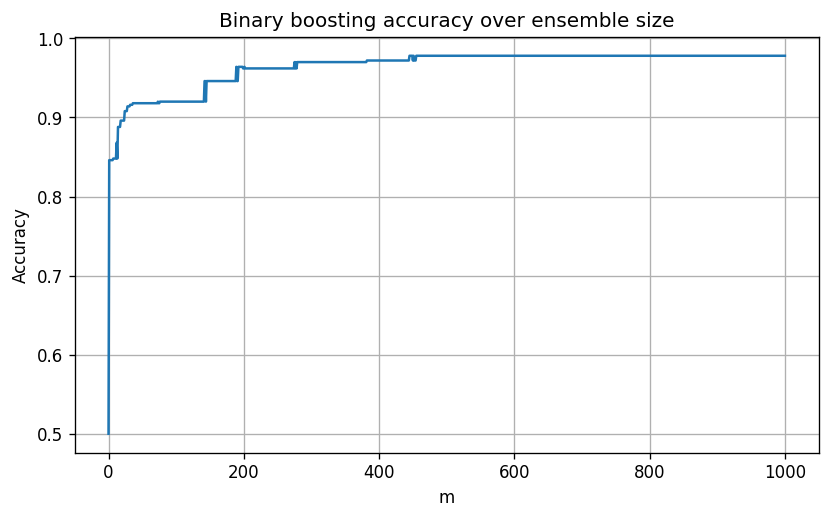

Accuracy at m=1: 0.8460
Accuracy at m=10: 0.8480
Accuracy at m=100: 0.9200
Accuracy at m=1000: 0.9780


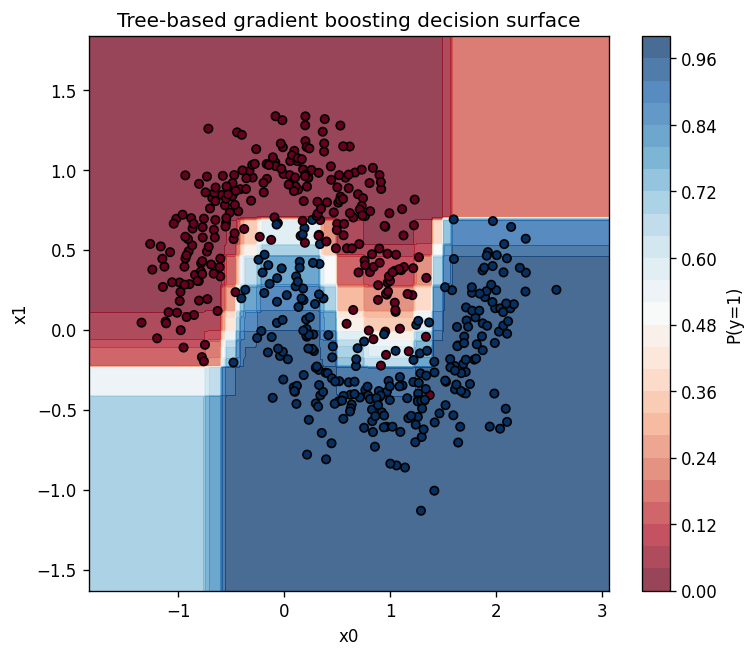

In [19]:
# ============================================================
# Problem 3.4.5
# Binary gradient boosting classification with tree weak learners
# ============================================================

gb_clf_df = pd.read_csv("gradient_boosting_classification.csv")
unnamed_cols = [col for col in gb_clf_df.columns if str(col).startswith("Unnamed")]
if unnamed_cols:
    gb_clf_df = gb_clf_df.drop(columns=unnamed_cols)

X_gb_clf = gb_clf_df[["x0", "x1"]].to_numpy(dtype=np.float32)
y_gb_clf = gb_clf_df["y"].to_numpy(dtype=np.int32)

tree_boost_clf = GradientBoostingBinaryClassifierScratch(
    base_estimator=DecisionTreeRegressor(max_depth=1, random_state=0),
    n_estimators=1000,
    learning_rate=0.5,
    initial_score=0.0,
 )
tree_boost_clf.fit(X_gb_clf, y_gb_clf)

accuracy_axis = np.arange(0, 1001)
plt.figure(figsize=(8, 4.5))
plt.plot(accuracy_axis, tree_boost_clf.train_accuracy_)
plt.title("Binary boosting accuracy over ensemble size")
plt.xlabel("m")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

for m in [1, 10, 100, 1000]:
    acc_m = accuracy_score(y_gb_clf, tree_boost_clf.predict(X_gb_clf, n_estimators=m))
    print(f"Accuracy at m={m}: {acc_m:.4f}")

x0_min, x0_max = X_gb_clf[:, 0].min() - 0.5, X_gb_clf[:, 0].max() + 0.5
x1_min, x1_max = X_gb_clf[:, 1].min() - 0.5, X_gb_clf[:, 1].max() + 0.5
grid_x0, grid_x1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 250),
    np.linspace(x1_min, x1_max, 250),
 )
grid_points = np.column_stack([grid_x0.ravel(), grid_x1.ravel()])
grid_prob = tree_boost_clf.predict_proba(grid_points)[:, 1].reshape(grid_x0.shape)

plt.figure(figsize=(7, 6))
plt.contourf(grid_x0, grid_x1, grid_prob, levels=25, cmap="RdBu", alpha=0.75)
plt.colorbar(label="P(y=1)")
plt.scatter(
    X_gb_clf[:, 0],
    X_gb_clf[:, 1],
    c=y_gb_clf,
    cmap="RdBu",
    edgecolors="black",
    s=25,
 )
plt.title("Tree-based gradient boosting decision surface")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

## Results — 3.4.5

Results: (paste outputs from the code cell here)



## 3.4.6

Again, switch the `DecisionTreeRegressor` for a `LinearRegression` scheme and compare the obtained ensemble to the results from Task 3.4.5.

Briefly discuss how the obtained decision surface differs.

---

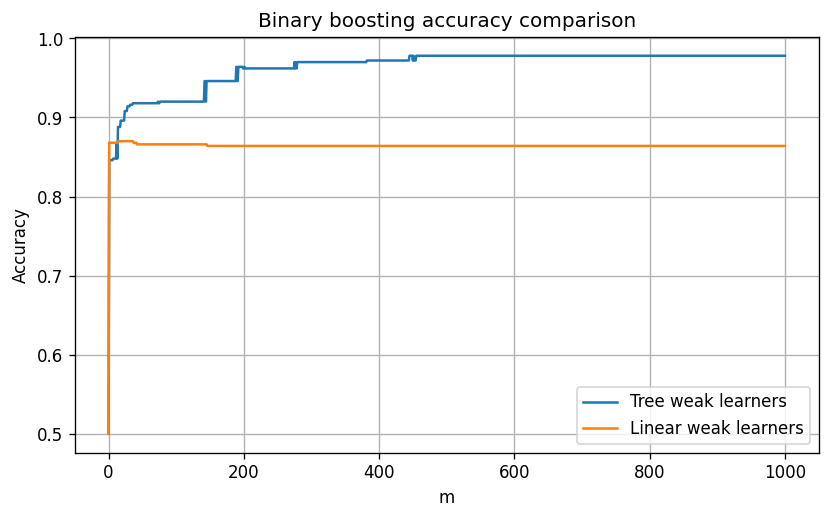

Linear weak learners accuracy at m=1: 0.8680
Linear weak learners accuracy at m=10: 0.8680
Linear weak learners accuracy at m=100: 0.8660
Linear weak learners accuracy at m=1000: 0.8640


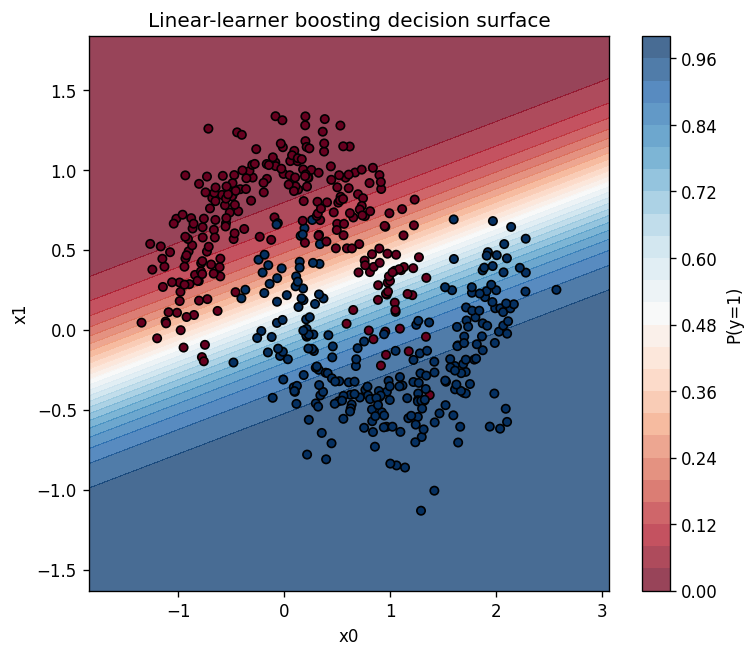

Tree final accuracy: 0.978
Linear final accuracy: 0.864

Discussion:
The linear version produces a much smoother decision surface.
Tree weak learners can create localized piecewise-constant corrections, which fits nonlinear class boundaries better.


In [23]:
# ============================================================
# Problem 3.4.6
# Binary gradient boosting classification with LinearRegression weak learners
# ============================================================

linear_boost_clf = GradientBoostingBinaryClassifierScratch(
    base_estimator=LinearRegression(),
    n_estimators=1000,
    learning_rate=0.5,
    initial_score=0.0,
 )
linear_boost_clf.fit(X_gb_clf, y_gb_clf)

plt.figure(figsize=(8, 4.5))
plt.plot(accuracy_axis, tree_boost_clf.train_accuracy_, label="Tree weak learners")
plt.plot(accuracy_axis, linear_boost_clf.train_accuracy_, label="Linear weak learners")
plt.title("Binary boosting accuracy comparison")
plt.xlabel("m")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

for m in [1, 10, 100, 1000]:
    acc_m = accuracy_score(y_gb_clf, linear_boost_clf.predict(X_gb_clf, n_estimators=m))
    print(f"Linear weak learners accuracy at m={m}: {acc_m:.4f}")

linear_grid_prob = linear_boost_clf.predict_proba(grid_points)[:, 1].reshape(grid_x0.shape)

plt.figure(figsize=(7, 6))
plt.contourf(grid_x0, grid_x1, linear_grid_prob, levels=25, cmap="RdBu", alpha=0.75)
plt.colorbar(label="P(y=1)")
plt.scatter(
    X_gb_clf[:, 0],
    X_gb_clf[:, 1],
    c=y_gb_clf,
    cmap="RdBu",
    edgecolors="black",
    s=25,
 )
plt.title("Linear-learner boosting decision surface")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

print("Tree final accuracy:", tree_boost_clf.train_accuracy_[-1])
print("Linear final accuracy:", linear_boost_clf.train_accuracy_[-1])
print()
print("Discussion:")
print("The linear version produces a much smoother decision surface.")
print("Tree weak learners can create localized piecewise-constant corrections, which fits nonlinear class boundaries better.")

## Results — 3.4.6

Results: (paste outputs from the code cell here)